# 04 · Benchmark Evaluation — EH3

Evaluates pharmacophore recovery (EH3) and direction accuracy on a
curated set of 17 well-characterised D₂/5-HT₂A ligands with known
selectivity-driving scaffolds.

| Group | Compounds | Purpose |
|---|---|---|
| G1 — 5HT₂A selective | Risperidone, Ketanserin, Clozapine, Volinanserin | Primary EH3 test |
| G1 — D2 selective | Raclopride, Sulpiride, Amisulpride | Primary EH3 test |
| G2 — inactive controls | Atropine, Naloxone, Caffeine, Scopolamine | Should show near-zero attribution |
| G3 — active non-selective | Spiperone, Pimozide, Thioridazine, Haloperidol, Chlorpromazine, Olanzapine | Direction accuracy only |

Asparagine excluded (data error — amino acid, no Ki data).

## 0. Imports

In [45]:
import sys, pickle, warnings, random, os, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
warnings.filterwarnings('ignore')

sys.path.insert(0, '.')
from utils import build_feature_matrix, expand_shap_to_fp, SEED, N_FP

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, rdFingerprintGenerator, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image

import torch
import torch.nn as nn
import shap

def seed_everything(seed=SEED):
    random.seed(seed); os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed)
    if torch.backends.mps.is_available(): torch.mps.manual_seed(seed)

seed_everything()
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
_gen   = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=N_FP)
print(f"Device: {DEVICE}")

Device: mps


## 1. Model architecture definitions

In [46]:
class PyramidMLP(nn.Module):
    def __init__(self, input_dim, dropout=0.25):
        super().__init__()
        dims = [512, 256, 128]
        layers, in_d = [], input_dim
        for h in dims:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h),
                       nn.GELU(), nn.Dropout(dropout)]
            in_d = h
        self.encoder = nn.Sequential(*layers)
        self.head     = nn.Linear(in_d, 1)
    def forward(self, x):
        return self.head(self.encoder(x)).squeeze(-1)

class TwoHeadMLP(nn.Module):
    def __init__(self, input_dim, dropout=0.25):
        super().__init__()
        shared = [512, 256]
        layers, in_d = [], input_dim
        for h in shared:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h),
                       nn.GELU(), nn.Dropout(dropout)]
            in_d = h
        self.encoder  = nn.Sequential(*layers)
        self.head_d2  = nn.Sequential(nn.Linear(in_d, 128), nn.GELU(), nn.Linear(128, 1))
        self.head_sht = nn.Sequential(nn.Linear(in_d, 128), nn.GELU(), nn.Linear(128, 1))
    def forward(self, x):
        h = self.encoder(x)
        return self.head_d2(h).squeeze(-1), self.head_sht(h).squeeze(-1)

print("Architecture classes defined.")

Architecture classes defined.


## 2. Load data and models

In [47]:
with open('data.pkl',   'rb') as f: data   = pickle.load(f)
with open('models.pkl', 'rb') as f: models = pickle.load(f)

merged = data['merged']
sp     = data['splits']
sel    = models['selectors']
sc     = models['scalers']

smiles_ov  = merged['curated_smiles'].tolist()
smiles_d2  = data['d2']['curated_smiles'].tolist()
smiles_sht = data['sht']['curated_smiles'].tolist()

X_ov  = data['X_ov']
X_d2  = data['X_d2']
X_sht = data['X_sht']

tr_ov = sp['tr_ov']

X_feat_ov  = build_feature_matrix(X_ov,  smiles_ov,  sel['overlap'], sc['overlap'])
X_feat_d2  = build_feature_matrix(X_d2,  smiles_d2,  sel['D2'],      sc['D2'])
X_feat_sht = build_feature_matrix(X_sht, smiles_sht, sel['5HT2A'],   sc['5HT2A'])

tb       = models['tree_best']
tree_A   = tb['A — direct Δ']
tree_B_d2  = tb['B — D2']
tree_B_sht = tb['B — 5HT2A']

mlp_A    = models['mlp_A'].to(DEVICE).eval()
mlp_B_d2 = models['mlp_B_d2'].to(DEVICE).eval()
mlp_B_sht= models['mlp_B_sht'].to(DEVICE).eval()
mlp_C    = models['mlp_C'].to(DEVICE).eval()

to_t = lambda a: torch.tensor(a, dtype=torch.float32).to(DEVICE)

# Background for interventional SHAP
rng   = np.random.RandomState(SEED)
bg_ov = X_feat_ov[tr_ov][rng.choice(len(tr_ov), 200, replace=False)]

print("Models and data loaded.")

Models and data loaded.


## 3. Load and prepare benchmark

Pharmacophore SMARTS are defined per compound based on the `expected_scaffold`
annotation. Each SMARTS matches the structural motif known to drive
D₂/5-HT₂A selectivity for that compound class.

In [48]:
bench_raw = pd.read_csv('explanation_benchmark_dataset.csv')

# Drop Asparagine (amino acid — data error)
bench = bench_raw[bench_raw['pref_name'] != 'ASPARAGINE'].copy().reset_index(drop=True)
print(f"Benchmark: {len(bench)} compounds")

# Use pre-computed delta_pKi directly (new dataset column)
# Rename Ki columns to match new naming convention
bench = bench.rename(columns={
    'Ki_5HT2A_nM': 'Ki_5HT2A_nM_median',
    'Ki_D2_nM':    'Ki_D2_nM_median',
})
bench['delta_pchembl'] = bench['delta_pKi']   # already computed by colleagues

# Flag G3 reclassification warnings
if 'g3_reclassification_warning' in bench.columns:
    warned = bench[bench['g3_reclassification_warning'].notna() &
                   (bench['g3_reclassification_warning'] != '')]
    if len(warned):
        print("\nG3 reclassification warnings:")
        for _, r in warned.iterrows():
            print(f"  {r['pref_name']}: {r['g3_reclassification_warning']}")

# Pharmacophore SMARTS — selectivity-driving substructures (validated vs SMILES)
PHARMA_SMARTS = {
    'RISPERIDONE':   'c1noc2ccccc12',                          # benzisoxazole
    'KETANSERIN':    'n1c(=O)[nH]c2ccccc2c1=O',                # quinazolinedione
    'CLOZAPINE':     'c1ccc2c(c1)Nc1ccccc1N=C2',               # dibenzodiazepine
    'VOLINANSERIN':  'c1ccc(CCN2CCC(Cc3ccccc3)CC2)cc1',       # diaryl-piperidine
    'RACLOPRIDE':    'NC(=O)c1ccccc1',                         # benzamide
    'SULPIRIDE':     'NC(=O)c1ccccc1',                         # benzamide
    'AMISULPRIDE':   'Nc1ccc(C(N)=O)cc1',                      # aminobenzamide
}

print('Pharmacophore SMARTS validation:')
for name, smarts in PHARMA_SMARTS.items():
    row = bench[bench['pref_name'] == name]
    if row.empty:
        print(f'  MISSING: {name} not in benchmark table')
        continue
    smi = row.iloc[0]['canonical_smiles']
    mol = Chem.MolFromSmiles(smi)
    pat = Chem.MolFromSmarts(smarts)
    if mol is None or pat is None:
        print(f'  INVALID: {name}')
        continue
    n = len(mol.GetSubstructMatches(pat))
    status = f'OK ({n} match)' if n else 'FAIL — no substructure match'
    print(f'  {status}: {name}')

print("\nΔpKi per compound:")
for _, r in bench.iterrows():
    d = f"{r['delta_pchembl']:+.3f}" if pd.notna(r['delta_pchembl']) else "n/a"
    note = f" [{r['classification_note']}]" if pd.notna(r.get('classification_note','')) and r.get('classification_note','') else ''
    print(f"  {r['pref_name']:20s} | {r['group']:30s} | Δ={d}{note}")

Benchmark: 17 compounds

G3 reclassification warnings:
  RISPERIDONE: False
  KETANSERIN: False
  CLOZAPINE: False
  VOLINANSERIN: False
  RACLOPRIDE: False
  SULPIRIDE: False
  AMISULPRIDE: False
  ATROPINE: False
  NALOXONE: False
  CAFFEINE: False
  SCOPOLAMINE: False
  SPIPERONE: True
  PIMOZIDE: True
  THIORIDAZINE: True
  HALOPERIDOL: True
  CHLORPROMAZINE: False
  OLANZAPINE: True
Pharmacophore SMARTS validation:
  OK (1 match): RISPERIDONE
  OK (1 match): KETANSERIN
  OK (1 match): CLOZAPINE
  OK (1 match): VOLINANSERIN
  OK (1 match): RACLOPRIDE
  OK (1 match): SULPIRIDE
  OK (1 match): AMISULPRIDE

ΔpKi per compound:
  RISPERIDONE          | Group 1 - 5HT2A selective      | Δ=+0.886 [ΔpKi=+0.89 (Ki_5HT2A=0.5, Ki_D2=3.8 nM)]
  KETANSERIN           | Group 1 - 5HT2A selective      | Δ=+2.752 [ΔpKi=+2.75 (Ki_5HT2A=0.4, Ki_D2=240.0 nM)]
  CLOZAPINE            | Group 1 - 5HT2A selective      | Δ=+1.058 [ΔpKi=+1.06 (Ki_5HT2A=9.1, Ki_D2=104.2 nM)]
  VOLINANSERIN         | Group 1 -

## 4. Feature computation and training-set contamination check

In [49]:
def smi_to_feat(smi, sel_key):
    """Convert a SMILES to feature vector using the fitted pipeline."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    fp  = _gen.GetFingerprintAsNumPy(mol).reshape(1, -1).astype(np.float32)
    return build_feature_matrix(fp, [smi], sel[sel_key], sc[sel_key])

# Build feature matrices for benchmark compounds
bench_feats = []
bench_valid = []
for _, row in bench.iterrows():
    smi  = row['canonical_smiles']
    feat = smi_to_feat(smi, 'overlap')
    if feat is not None:
        bench_feats.append(feat[0])
        bench_valid.append(True)
    else:
        bench_feats.append(None)
        bench_valid.append(False)
        print(f"  WARNING: invalid SMILES for {row['pref_name']}")

bench['feat_valid'] = bench_valid
X_bench = np.array([f for f in bench_feats if f is not None], dtype=np.float32)
bench_ok = bench[bench['feat_valid']].copy().reset_index(drop=True)
print(f"Valid feature vectors: {len(bench_ok)} / {len(bench)}")

# Contamination check — are any benchmark compounds in the training set?
print("\nContamination check (Tanimoto ≥ 0.9 with training set):")
from rdkit import DataStructs
contam_found = False
for _, row in bench_ok.iterrows():
    mol_b = Chem.MolFromSmiles(row['canonical_smiles'])
    fp_b  = _gen.GetFingerprint(mol_b)
    for smi_tr in smiles_ov[:len(tr_ov)]:
        mol_tr = Chem.MolFromSmiles(smi_tr)
        if mol_tr is None: continue
        sim = DataStructs.TanimotoSimilarity(_gen.GetFingerprint(mol_tr), fp_b)
        if sim >= 0.9:
            print(f"  {row['pref_name']} → Tanimoto={sim:.3f} with training compound")
            contam_found = True
            break
if not contam_found:
    print("  No contamination found (all Tanimoto < 0.9 with training set)")

Valid feature vectors: 17 / 17

Contamination check (Tanimoto ≥ 0.9 with training set):
  RISPERIDONE → Tanimoto=1.000 with training compound
  CLOZAPINE → Tanimoto=1.000 with training compound
  VOLINANSERIN → Tanimoto=1.000 with training compound
  AMISULPRIDE → Tanimoto=1.000 with training compound
  SPIPERONE → Tanimoto=1.000 with training compound
  THIORIDAZINE → Tanimoto=1.000 with training compound
  HALOPERIDOL → Tanimoto=1.000 with training compound
  CHLORPROMAZINE → Tanimoto=1.000 with training compound
  OLANZAPINE → Tanimoto=1.000 with training compound


## 5. Model predictions and direction accuracy

In [50]:
# Tree A — overlap features
bench_ok['pred_tree_A'] = tree_A.predict(X_bench)

# Tree B — each receptor model uses its OWN feature space
# Build benchmark feature vectors for D2 and 5HT2A selectors separately
X_bench_d2  = np.array([
    smi_to_feat(smi, 'D2')[0]
    for smi in bench_ok['canonical_smiles']
], dtype=np.float32)

X_bench_sht = np.array([
    smi_to_feat(smi, '5HT2A')[0]
    for smi in bench_ok['canonical_smiles']
], dtype=np.float32)

print(f"Feature dims — overlap: {X_bench.shape[1]}  D2: {X_bench_d2.shape[1]}  5HT2A: {X_bench_sht.shape[1]}")

bench_ok['pred_tree_B'] = (tree_B_sht.predict(X_bench_sht) -
                            tree_B_d2.predict(X_bench_d2))

# MLP B also uses D2 / 5HT2A feature spaces
with torch.no_grad():
    bench_ok['pred_mlp_A'] = mlp_A(to_t(X_bench)).cpu().numpy()
    bench_ok['pred_mlp_B'] = (mlp_B_sht(to_t(X_bench_sht)).cpu().numpy() -
                               mlp_B_d2(to_t(X_bench_d2)).cpu().numpy())
    pd2_c, psht_c = mlp_C(to_t(X_bench))
    bench_ok['pred_mlp_C'] = psht_c.cpu().numpy() - pd2_c.cpu().numpy()

# Direction accuracy — Group 1
g1 = bench_ok[bench_ok['group'].str.startswith('Group 1')].copy()

def direction_acc(df, pred_col):
    results = []
    for _, row in df.iterrows():
        if pd.isna(row['delta_pchembl']): continue
        results.append(np.sign(row['delta_pchembl']) == np.sign(row[pred_col]))
    return np.mean(results) if results else np.nan

print("\nDirection accuracy — Group 1 (Ki-based ground truth):")
print(f"{'Model':20s} | {'Acc':>6s}")
print("-"*30)
for col, label in [('pred_tree_A','Tree A'), ('pred_tree_B','Tree B'),
                    ('pred_mlp_A','MLP A'),  ('pred_mlp_B','MLP B'),
                    ('pred_mlp_C','MLP C')]:
    acc = direction_acc(g1, col)
    print(f"  {label:18s} | {acc:>5.1%}")

print("\nPredictions vs expected ΔpChEMBL:")
print(f"{'Compound':20s} | {'Expected Δ':>10s} | {'Tree A':>8s} | {'MLP A':>7s} | {'MLP B':>7s} | {'MLP C':>7s}")
print("-"*70)
for _, row in bench_ok.iterrows():
    exp = f"{row['delta_pchembl']:+.3f}" if pd.notna(row['delta_pchembl']) else "    n/a"
    print(f"  {row['pref_name']:18s} | {exp:>10s} | "
          f"{row['pred_tree_A']:>+8.3f} | {row['pred_mlp_A']:>+7.3f} | "
          f"{row['pred_mlp_B']:>+7.3f} | {row['pred_mlp_C']:>+7.3f}")

Feature dims — overlap: 687  D2: 814  5HT2A: 768

Direction accuracy — Group 1 (Ki-based ground truth):
Model                |    Acc
------------------------------
  Tree A             | 100.0%
  Tree B             | 100.0%
  MLP A              | 100.0%
  MLP B              | 100.0%
  MLP C              | 100.0%

Predictions vs expected ΔpChEMBL:
Compound             | Expected Δ |   Tree A |   MLP A |   MLP B |   MLP C
----------------------------------------------------------------------
  RISPERIDONE        |     +0.886 |   +1.739 |  +1.679 |  +0.837 |  +1.524
  KETANSERIN         |     +2.752 |   +2.259 |  +2.625 |  +2.503 |  +2.116
  CLOZAPINE          |     +1.058 |   +1.376 |  +0.950 |  +1.662 |  +1.868
  VOLINANSERIN       |     +3.623 |   +2.647 |  +3.203 |  +3.466 |  +2.579
  RACLOPRIDE         |        n/a |   -0.425 |  -1.232 |  -3.434 |  -0.839
  SULPIRIDE          |        n/a |   -1.295 |  -1.201 |  -2.983 |  -1.100
  AMISULPRIDE        |     -1.908 |   -1.549 |  -1.769

## 6. SHAP attributions — interventional (tree) + GradientSHAP (MLP)

In [51]:
from captum.attr import GradientShap

# Fix numpy 2.x compatibility for captum
if not hasattr(np, 'bool'):   np.bool   = bool
if not hasattr(np, 'int'):    np.int    = int
if not hasattr(np, 'float'):  np.float  = float

kw = dict(feature_perturbation='interventional')

print("Computing attributions...")
print("  Tree A (interventional SHAP)...")
sv_tree_A  = shap.TreeExplainer(tree_A, data=bg_ov, **kw).shap_values(X_bench)
shap_tree_A = expand_shap_to_fp(sv_tree_A, sel['overlap'])

print("  Tree B (interventional SHAP)...")
# Tree B uses separate D2/5HT2A feature spaces — need separate backgrounds
bg_d2  = X_feat_d2[sp['tr_d2']][rng.choice(len(sp['tr_d2']), 200, replace=False)]
bg_sht = X_feat_sht[sp['tr_sht']][rng.choice(len(sp['tr_sht']), 200, replace=False)]
sv_Bd2  = shap.TreeExplainer(tree_B_d2,  data=bg_d2,  **kw).shap_values(X_bench_d2)
sv_Bsht = shap.TreeExplainer(tree_B_sht, data=bg_sht, **kw).shap_values(X_bench_sht)
shap_tree_B = (expand_shap_to_fp(sv_Bsht, sel['5HT2A']) -
               expand_shap_to_fp(sv_Bd2,  sel['D2']))

print("  MLP A (GradientSHAP)...")
gs = GradientShap(mlp_A)
sv = gs.attribute(to_t(X_bench), to_t(bg_ov[:50]),
                   n_samples=50, stdevs=0.09,
                   return_convergence_delta=False)
shap_mlp_A = expand_shap_to_fp(sv.detach().cpu().numpy(), sel['overlap'])

print("  MLP B (GradientSHAP)...")
gs_d2  = GradientShap(mlp_B_d2)
gs_sht = GradientShap(mlp_B_sht)
sv_d2  = gs_d2.attribute(to_t(X_bench_d2), to_t(bg_d2[:50]),
                          n_samples=50, stdevs=0.09,
                          return_convergence_delta=False)
sv_sht = gs_sht.attribute(to_t(X_bench_sht), to_t(bg_sht[:50]),
                            n_samples=50, stdevs=0.09,
                            return_convergence_delta=False)
shap_mlp_B = (expand_shap_to_fp(sv_sht.detach().cpu().numpy(), sel['5HT2A']) -
              expand_shap_to_fp(sv_d2.detach().cpu().numpy(),  sel['D2']))

print("  MLP C (GradientSHAP, two heads)...")
class HeadWrapper(nn.Module):
    def __init__(self, m, i): super().__init__(); self.m=m; self.i=i
    def forward(self, x): return self.m(x)[self.i].unsqueeze(-1)

for head_i, head_name in [(0, 'd2'), (1, 'sht')]:
    hw  = HeadWrapper(mlp_C, head_i)
    gsh = GradientShap(hw)
    sv  = gsh.attribute(to_t(X_bench), to_t(bg_ov[:50]),
                         n_samples=50, stdevs=0.09,
                         return_convergence_delta=False)
    if head_name == 'd2':  sv_Cd2  = expand_shap_to_fp(sv.detach().cpu().numpy(), sel['overlap'])
    else:                  sv_Csht = expand_shap_to_fp(sv.detach().cpu().numpy(), sel['overlap'])

shap_mlp_C = sv_Csht - sv_Cd2

print(f"Done. Shapes: tree_A={shap_tree_A.shape}  mlp_A={shap_mlp_A.shape}")

Computing attributions...
  Tree A (interventional SHAP)...
  Tree B (interventional SHAP)...
  MLP A (GradientSHAP)...
  MLP B (GradientSHAP)...
  MLP C (GradientSHAP, two heads)...
Done. Shapes: tree_A=(17, 2048)  mlp_A=(17, 2048)


### SHAP pipeline audit

Attributions are **not** scaled or normalised before recall. The only transforms are:

| Step | What happens | Affects recall? |
|------|----------------|-----------------|
| `expand_shap_to_fp` | Maps FP-column SHAP back to 2048-bit Morgan space; **drops physchem descriptor columns** | Yes — EH3 is FP-only by design |
| MLP B / C | Subtract expanded 5HT2A − D2 vectors in shared bit index space | Yes — intentional post-hoc / multi-head |
| Recall ranking | Uses **\|SHAP\|** (sign-agnostic) | Yes — intentional |
| Bit pool | Ranks **active Morgan bits ∩ model feature mask** (not all 2048 bits) | Critical — ranking over variance-filtered bits (SHAP = 0) inflated random baseline |

Run the next cell to verify efficiency (TreeSHAP) and bit-pool sizes.

## 7. Pharmacophore recovery — EH3

For each Group 1 compound, the pharmacophore SMARTS is matched against
the molecule to find which Morgan bits overlap with the matched atoms.
Recovery = fraction of pharmacophore bits appearing in top-k SHAP features.
Active-bit filter applied: only bits present in the molecule are ranked.

In [52]:
def get_active_bits(smi):
    """Morgan bits present in the molecule (same generator as training)."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return set()
    arr = _gen.GetFingerprintAsNumPy(mol)
    return set(int(i) for i in np.where(arr > 0)[0])

def _selector_union_mask(*sel_keys):
    m = np.zeros(N_FP, dtype=bool)
    for key in sel_keys:
        m |= sel[key].get_support()
    return m

APPROACH_MASK = {
    'Tree A': _selector_union_mask('overlap'),
    'MLP A':  _selector_union_mask('overlap'),
    'MLP C':  _selector_union_mask('overlap'),
    'Tree B': _selector_union_mask('D2', '5HT2A'),
    'MLP B':  _selector_union_mask('D2', '5HT2A'),
}

def get_rank_bits(smi, approach):
    """Active Morgan bits that the model can attribute (not variance-filtered out)."""
    mask = APPROACH_MASK[approach]
    return {b for b in get_active_bits(smi) if mask[b]}

def get_pharma_bits(smi, smarts, approach='Tree A'):
    """Morgan bits overlapping SMARTS-matched atoms, restricted to model-visible bits."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return set()
    pat = Chem.MolFromSmarts(smarts)
    if pat is None:
        return set()
    matches = mol.GetSubstructMatches(pat)
    if not matches:
        return set()
    match_atoms = set(a for match in matches for a in match)

    bi = {}
    rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, 2, nBits=N_FP, bitInfo=bi)
    bits = {bit for bit, env_list in bi.items()
            if any(a in match_atoms for a, r in env_list)}
    mask = APPROACH_MASK[approach]
    return {b for b in bits if mask[b]}

def recall_at_k(shap_vec, pharma_bits, rank_bits, k):
    """Fraction of model-visible pharma bits in top-k |SHAP| over rank_bits."""
    if not pharma_bits or not rank_bits:
        return np.nan
    k = min(k, len(rank_bits))
    scores = {b: abs(float(shap_vec[b])) for b in rank_bits}
    top = set(sorted(scores, key=scores.get, reverse=True)[:k])
    return len(top & pharma_bits) / len(pharma_bits)

def pharma_recovery(shap_vec, pharma_bits, rank_bits, top_k=10):
    return recall_at_k(shap_vec, pharma_bits, rank_bits, top_k)

def expected_random_recall(k, rank_bits):
    """E[recall@k] when k bits are sampled uniformly from rank_bits."""
    if not rank_bits:
        return np.nan
    return min(k, len(rank_bits)) / len(rank_bits)

# Compute pharmacophore recovery for Group 1 compounds
g1_bench = bench_ok[bench_ok['group'].str.startswith('Group 1')].copy().reset_index(drop=True)

rows = []
for i, row in g1_bench.iterrows():
    name   = row['pref_name']
    smi    = row['canonical_smiles']
    smarts = PHARMA_SMARTS.get(name)
    if smarts is None:
        print(f"  No SMARTS defined for {name}")
        continue

    a_bits = get_rank_bits(smi, 'Tree A')  # reference pool for reporting
    p_all  = get_pharma_bits(smi, smarts, 'Tree A')
    bench_idx = bench_ok[bench_ok['pref_name'] == name].index[0]

    rec = {}
    for label, sv in [('Tree A', shap_tree_A), ('Tree B', shap_tree_B),
                       ('MLP A',  shap_mlp_A),  ('MLP B',  shap_mlp_B),
                       ('MLP C',  shap_mlp_C)]:
        r_bits = get_rank_bits(smi, label)
        p_bits = get_pharma_bits(smi, smarts, label)
        rec[label] = pharma_recovery(sv[bench_idx], p_bits, r_bits, top_k=10)

    rows.append({'compound': name, 'group': row['group'],
                 'n_pharma_bits': len(p_all), 'n_active_bits': len(a_bits),
                 **rec})
    print(f"  {name:20s} | pharma_bits={len(p_all):3d} | "
          + " | ".join([f"{l}={rec[l]:.2f}" for l in ['Tree A','MLP A','MLP B','MLP C']]))

rec_df = pd.DataFrame(rows)
print("\nMean pharmacophore recovery @ top-10 (Group 1):")
print(f"{'Approach':10s} | {'Mean':>6s}")
for col in ['Tree A', 'Tree B', 'MLP A', 'MLP B', 'MLP C']:
    print(f"  {col:10s} | {rec_df[col].mean():>6.3f}")

  RISPERIDONE          | pharma_bits= 19 | Tree A=0.16 | MLP A=0.16 | MLP B=0.16 | MLP C=0.16
  KETANSERIN           | pharma_bits= 17 | Tree A=0.35 | MLP A=0.24 | MLP B=0.25 | MLP C=0.35
  CLOZAPINE            | pharma_bits= 21 | Tree A=0.33 | MLP A=0.38 | MLP B=0.36 | MLP C=0.38
  VOLINANSERIN         | pharma_bits= 29 | Tree A=0.31 | MLP A=0.28 | MLP B=0.24 | MLP C=0.31
  RACLOPRIDE           | pharma_bits= 12 | Tree A=0.25 | MLP A=0.33 | MLP B=0.12 | MLP C=0.25
  SULPIRIDE            | pharma_bits= 16 | Tree A=0.31 | MLP A=0.19 | MLP B=0.17 | MLP C=0.19
  AMISULPRIDE          | pharma_bits= 16 | Tree A=0.25 | MLP A=0.25 | MLP B=0.25 | MLP C=0.19

Mean pharmacophore recovery @ top-10 (Group 1):
Approach   |   Mean
  Tree A     |  0.281
  Tree B     |  0.207
  MLP A      |  0.260
  MLP B      |  0.221
  MLP C      |  0.261


## 8. EH0 — Explainability-performance decoupling

Does higher model performance (lower RMSE) imply better pharmacophore recovery?
Tests across Tree A, MLP A using their respective val R² and pharmacophore recovery.

In [53]:
from sklearn.metrics import mean_squared_error

# Val metrics (Approach A, from notebook 02)
val_metrics = {
    'Tree A':  {'val_r2': 0.612, 'model': 'tree'},
    'MLP A':   {'val_r2': 0.641, 'model': 'mlp'},
}

pharma_means = {
    col: rec_df[col].mean()
    for col in ['Tree A', 'MLP A']
    if col in rec_df.columns
}

print("EH0 — Performance vs pharmacophore recovery:")
print(f"{'Model':10s} | {'Val R²':>8s} | {'Pharma recovery':>16s}")
print("-"*42)
for label in ['Tree A', 'MLP A']:
    r2  = val_metrics[label]['val_r2']
    rec = pharma_means.get(label, np.nan)
    print(f"  {label:10s} | {r2:>8.3f} | {rec:>16.3f}")

rho = None
if len(pharma_means) >= 2:
    r2s  = [val_metrics[l]['val_r2'] for l in pharma_means]
    recs = [pharma_means[l] for l in pharma_means]
    rho, p = spearmanr(r2s, recs)
    print(f"\nSpearman ρ(val R², recovery): {rho:.4f}  p={p:.4f}")
    print(f"Note: n={len(r2s)} models — this is illustrative, not statistically powered.")
    print("Higher performance does not necessarily = better explanations.")

EH0 — Performance vs pharmacophore recovery:
Model      |   Val R² |  Pharma recovery
------------------------------------------
  Tree A     |    0.612 |            0.281
  MLP A      |    0.641 |            0.260

Spearman ρ(val R², recovery): -1.0000  p=nan
Note: n=2 models — this is illustrative, not statistically powered.
Higher performance does not necessarily = better explanations.


## 9. Results summary

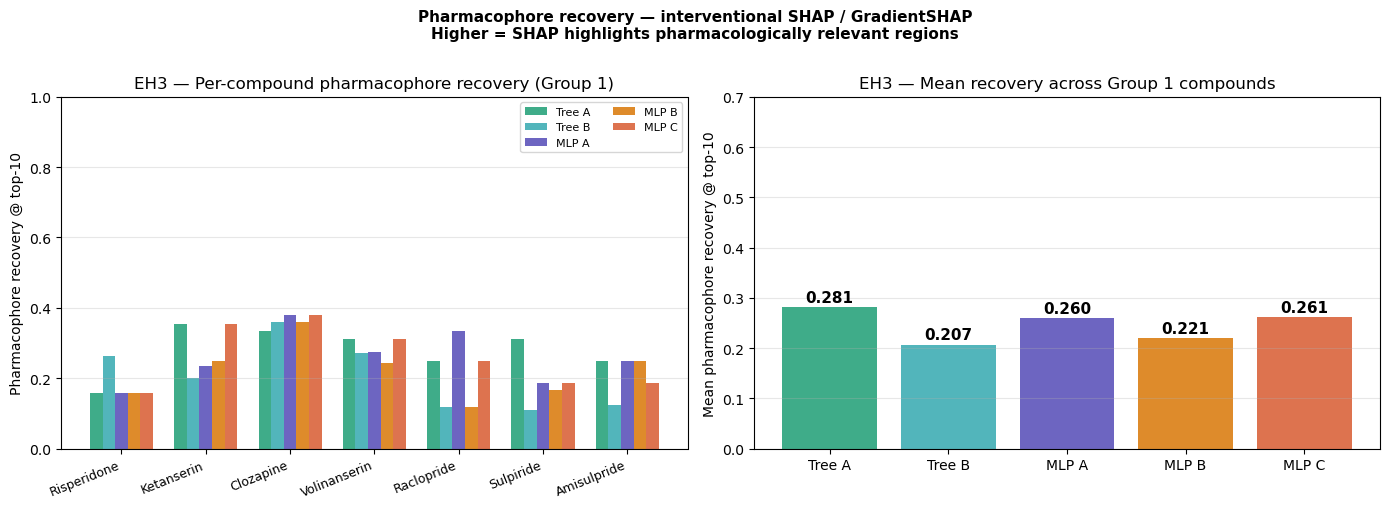


EH3 results (mean pharmacophore recovery @ top-10):
  Tree A    : 0.2810
  MLP C     : 0.2610
  MLP A     : 0.2601
  MLP B     : 0.2207
  Tree B    : 0.2071

EH3 ordering (MLP):
  direct=0.260  multi=0.261  post-hoc=0.221
  → Partially supported: direct ≥ post-hoc (multi ordering unclear)


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: pharmacophore recovery per compound × approach
approaches = ['Tree A', 'Tree B', 'MLP A', 'MLP B', 'MLP C']
colors     = ['#1D9E75','#34A8B0','#534AB7','#D97706','#D85A30']
x = np.arange(len(rec_df))
w = 0.15

for j, (approach, col) in enumerate(zip(approaches, colors)):
    vals = rec_df[approach].values
    axes[0].bar(x + (j - 2) * w, vals, w, label=approach,
                color=col, alpha=0.85, edgecolor='none')

axes[0].set_xticks(x)
axes[0].set_xticklabels(rec_df['compound'].str.capitalize(), rotation=22, ha='right', fontsize=9)
axes[0].set(ylabel='Pharmacophore recovery @ top-10',
            title='EH3 — Per-compound pharmacophore recovery (Group 1)', ylim=[0, 1])
axes[0].legend(fontsize=8, ncol=2); axes[0].grid(alpha=0.3, axis='y')

# Right: mean recovery per approach
means = [rec_df[a].mean() for a in approaches]
bars  = axes[1].bar(approaches, means, color=colors, alpha=0.85, edgecolor='none')
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set(ylabel='Mean pharmacophore recovery @ top-10',
            title='EH3 — Mean recovery across Group 1 compounds', ylim=[0, 0.7])
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Pharmacophore recovery — interventional SHAP / GradientSHAP\n'
             'Higher = SHAP highlights pharmacologically relevant regions',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_04_pharma_recovery.png', dpi=130, bbox_inches='tight')
plt.show()

# Final EH3 verdict
best = max(zip(means, approaches))
print(f"\nEH3 results (mean pharmacophore recovery @ top-10):")
for a, m in sorted(zip(approaches, means), key=lambda x: -x[1]):
    print(f"  {a:10s}: {m:.4f}")

direct = dict(zip(approaches, means))['MLP A']
posthoc = dict(zip(approaches, means))['MLP B']
multi  = dict(zip(approaches, means)).get('MLP C', np.nan)

print(f"\nEH3 ordering (MLP):")
print(f"  direct={direct:.3f}  multi={multi:.3f}  post-hoc={posthoc:.3f}")
if direct >= multi >= posthoc:
    print("  → Supported: direct ≥ multi ≥ post-hoc")
elif direct >= posthoc:
    print("  → Partially supported: direct ≥ post-hoc (multi ordering unclear)")
else:
    print("  → Not supported")

## 10. Fragment visualisation — pharmacophore overlay

Global vmax (99th percentile |SHAP|): 0.04883

Mean |SHAP| per compound (should be lower for G2 inactive controls):
Compound             | Group                          |    MLP A |    MLP B |    MLP C
--------------------------------------------------------------------------------
  RISPERIDONE        | Group 1 - 5HT2A selective    |  0.00300 |  0.00322 |  0.00237
  KETANSERIN         | Group 1 - 5HT2A selective    |  0.00264 |  0.00362 |  0.00232
  CLOZAPINE          | Group 1 - 5HT2A selective    |  0.00247 |  0.00375 |  0.00183
  VOLINANSERIN       | Group 1 - 5HT2A selective    |  0.00310 |  0.00364 |  0.00237
  RACLOPRIDE         | Group 1 - D2 selective       |  0.00284 |  0.00509 |  0.00261
  SULPIRIDE          | Group 1 - D2 selective       |  0.00251 |  0.00410 |  0.00216
  AMISULPRIDE        | Group 1 - D2 selective       |  0.00249 |  0.00407 |  0.00244
  ATROPINE           | Group 2 - inactive controls  |  0.00306 |  0.00348 |  0.00216
  NALOXONE           | Group 2 - ina

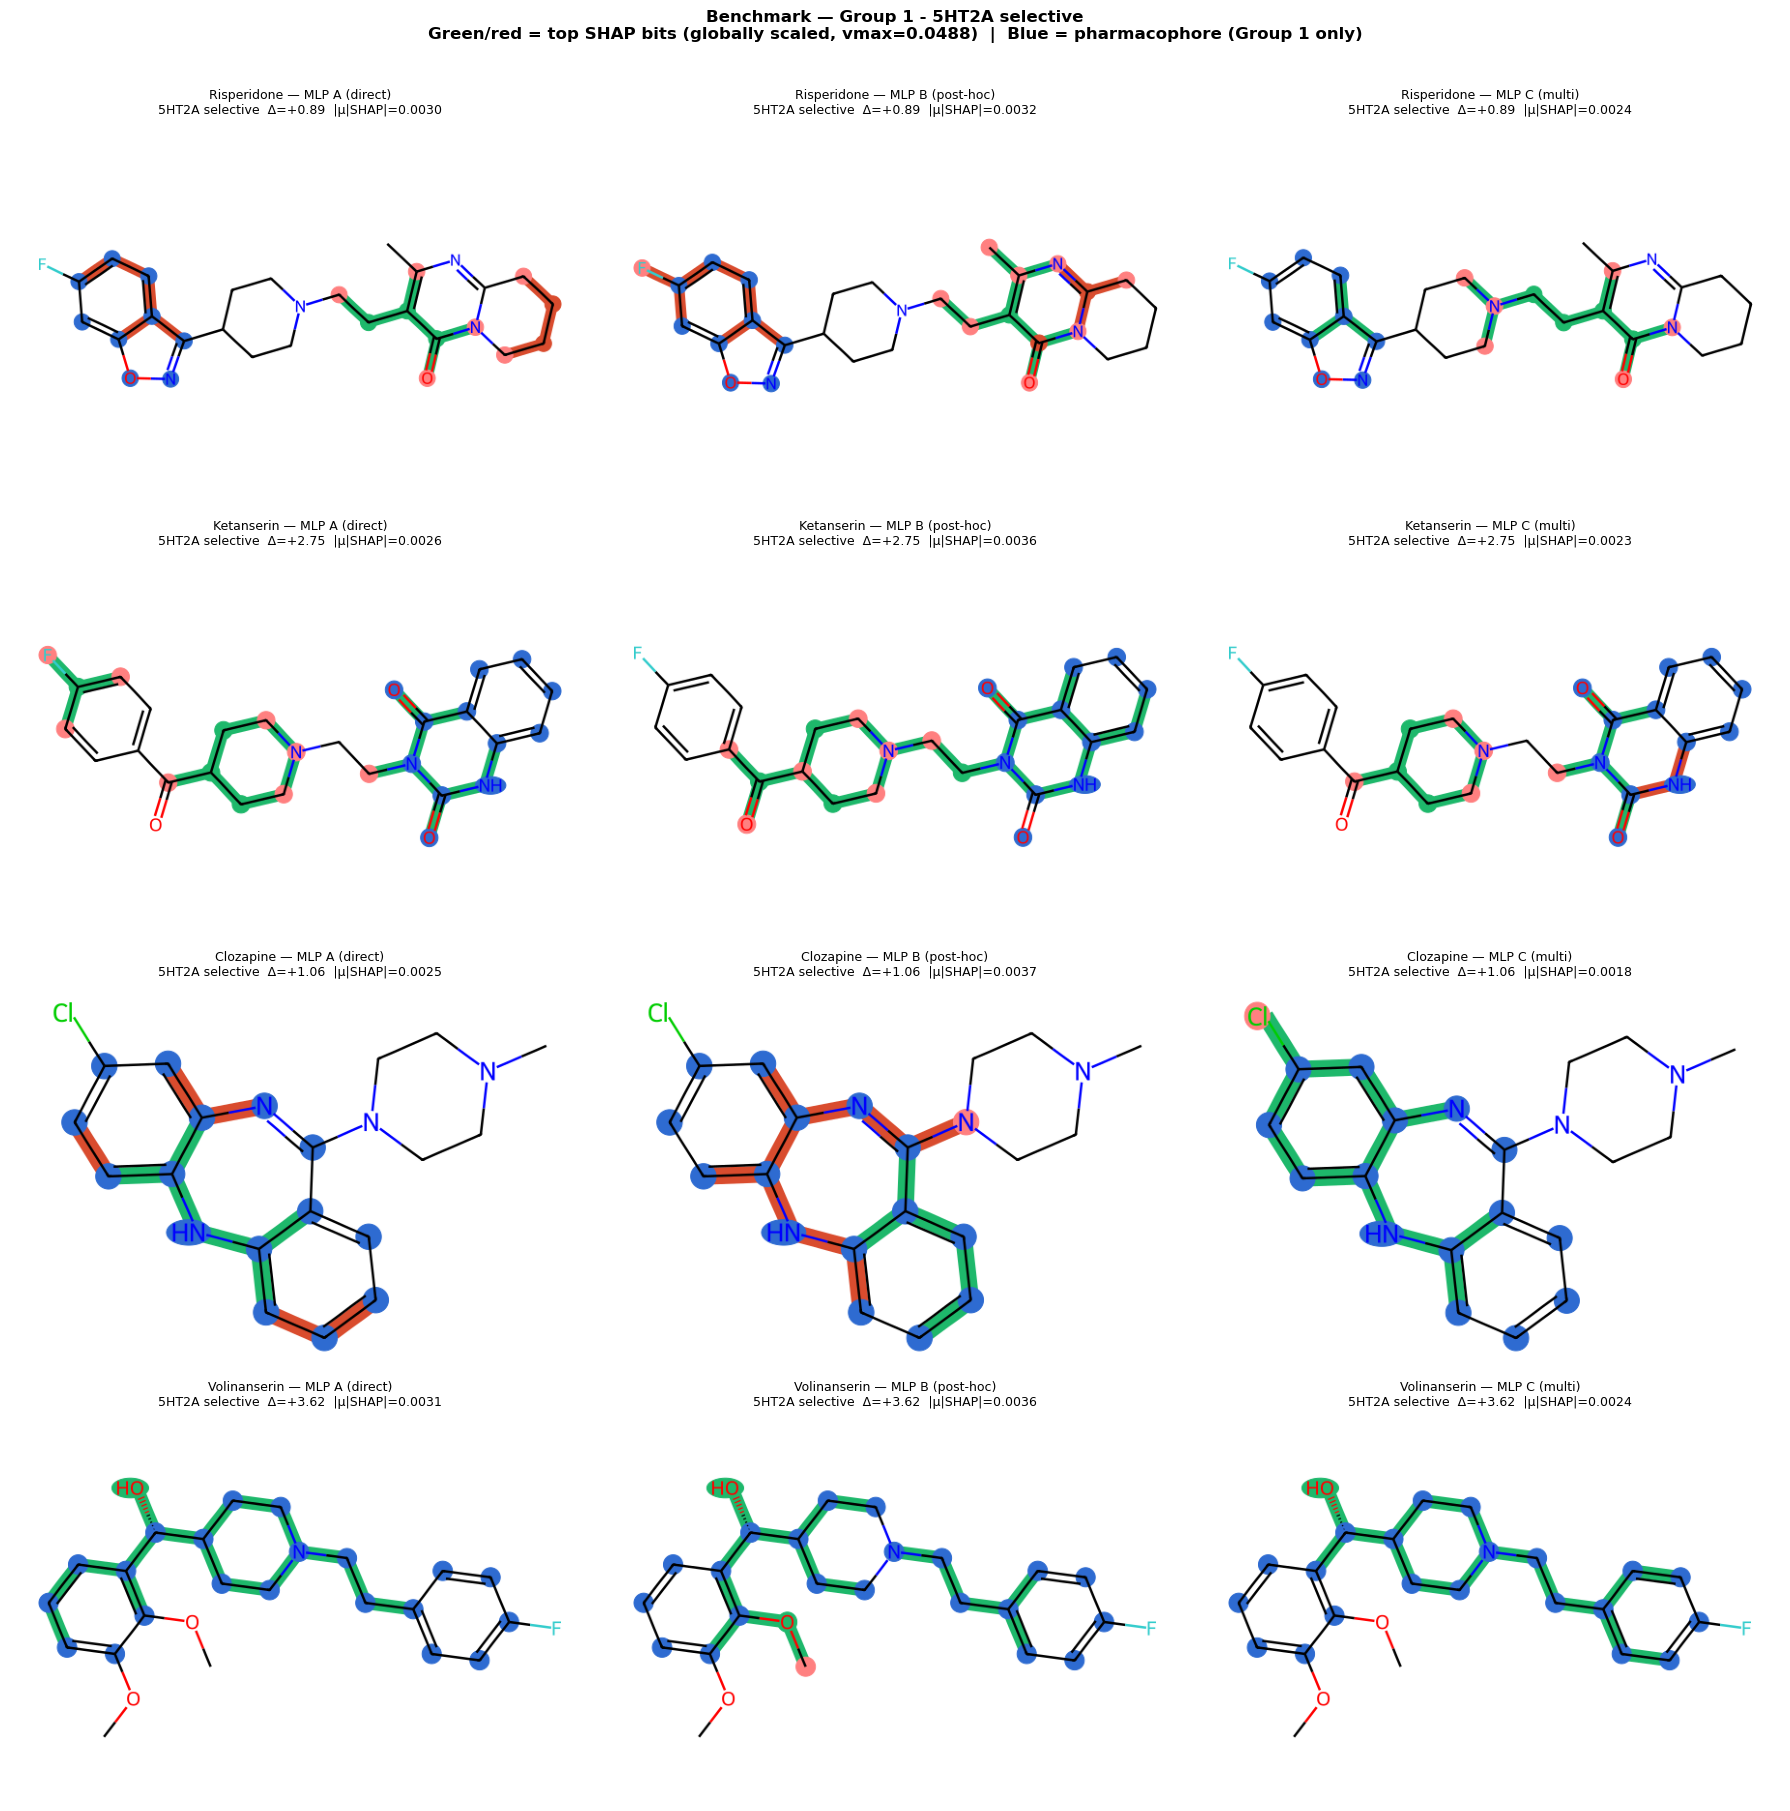

Saved: fig_04_group_1__5ht2a_selective.png


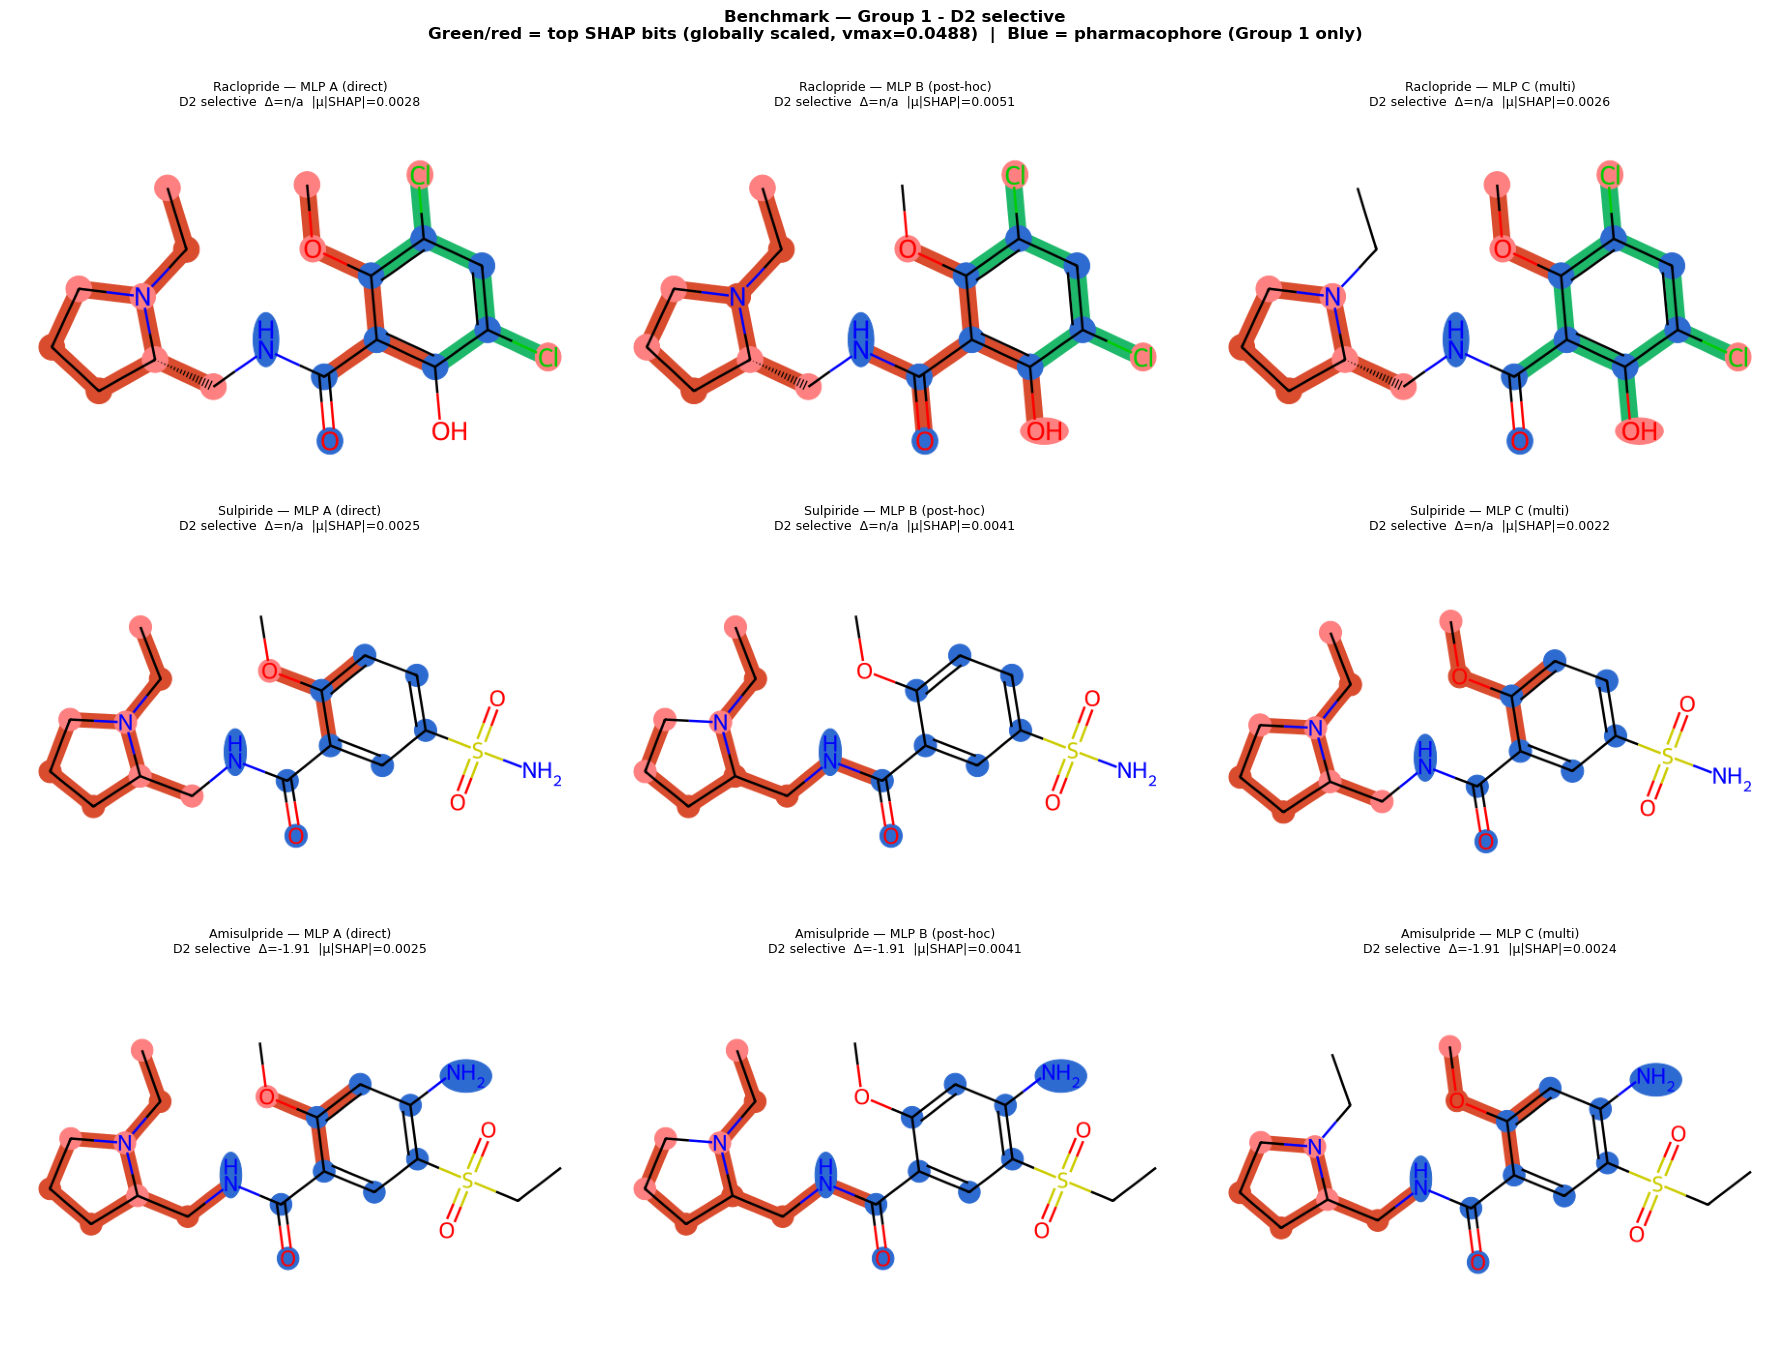

Saved: fig_04_group_1__d2_selective.png


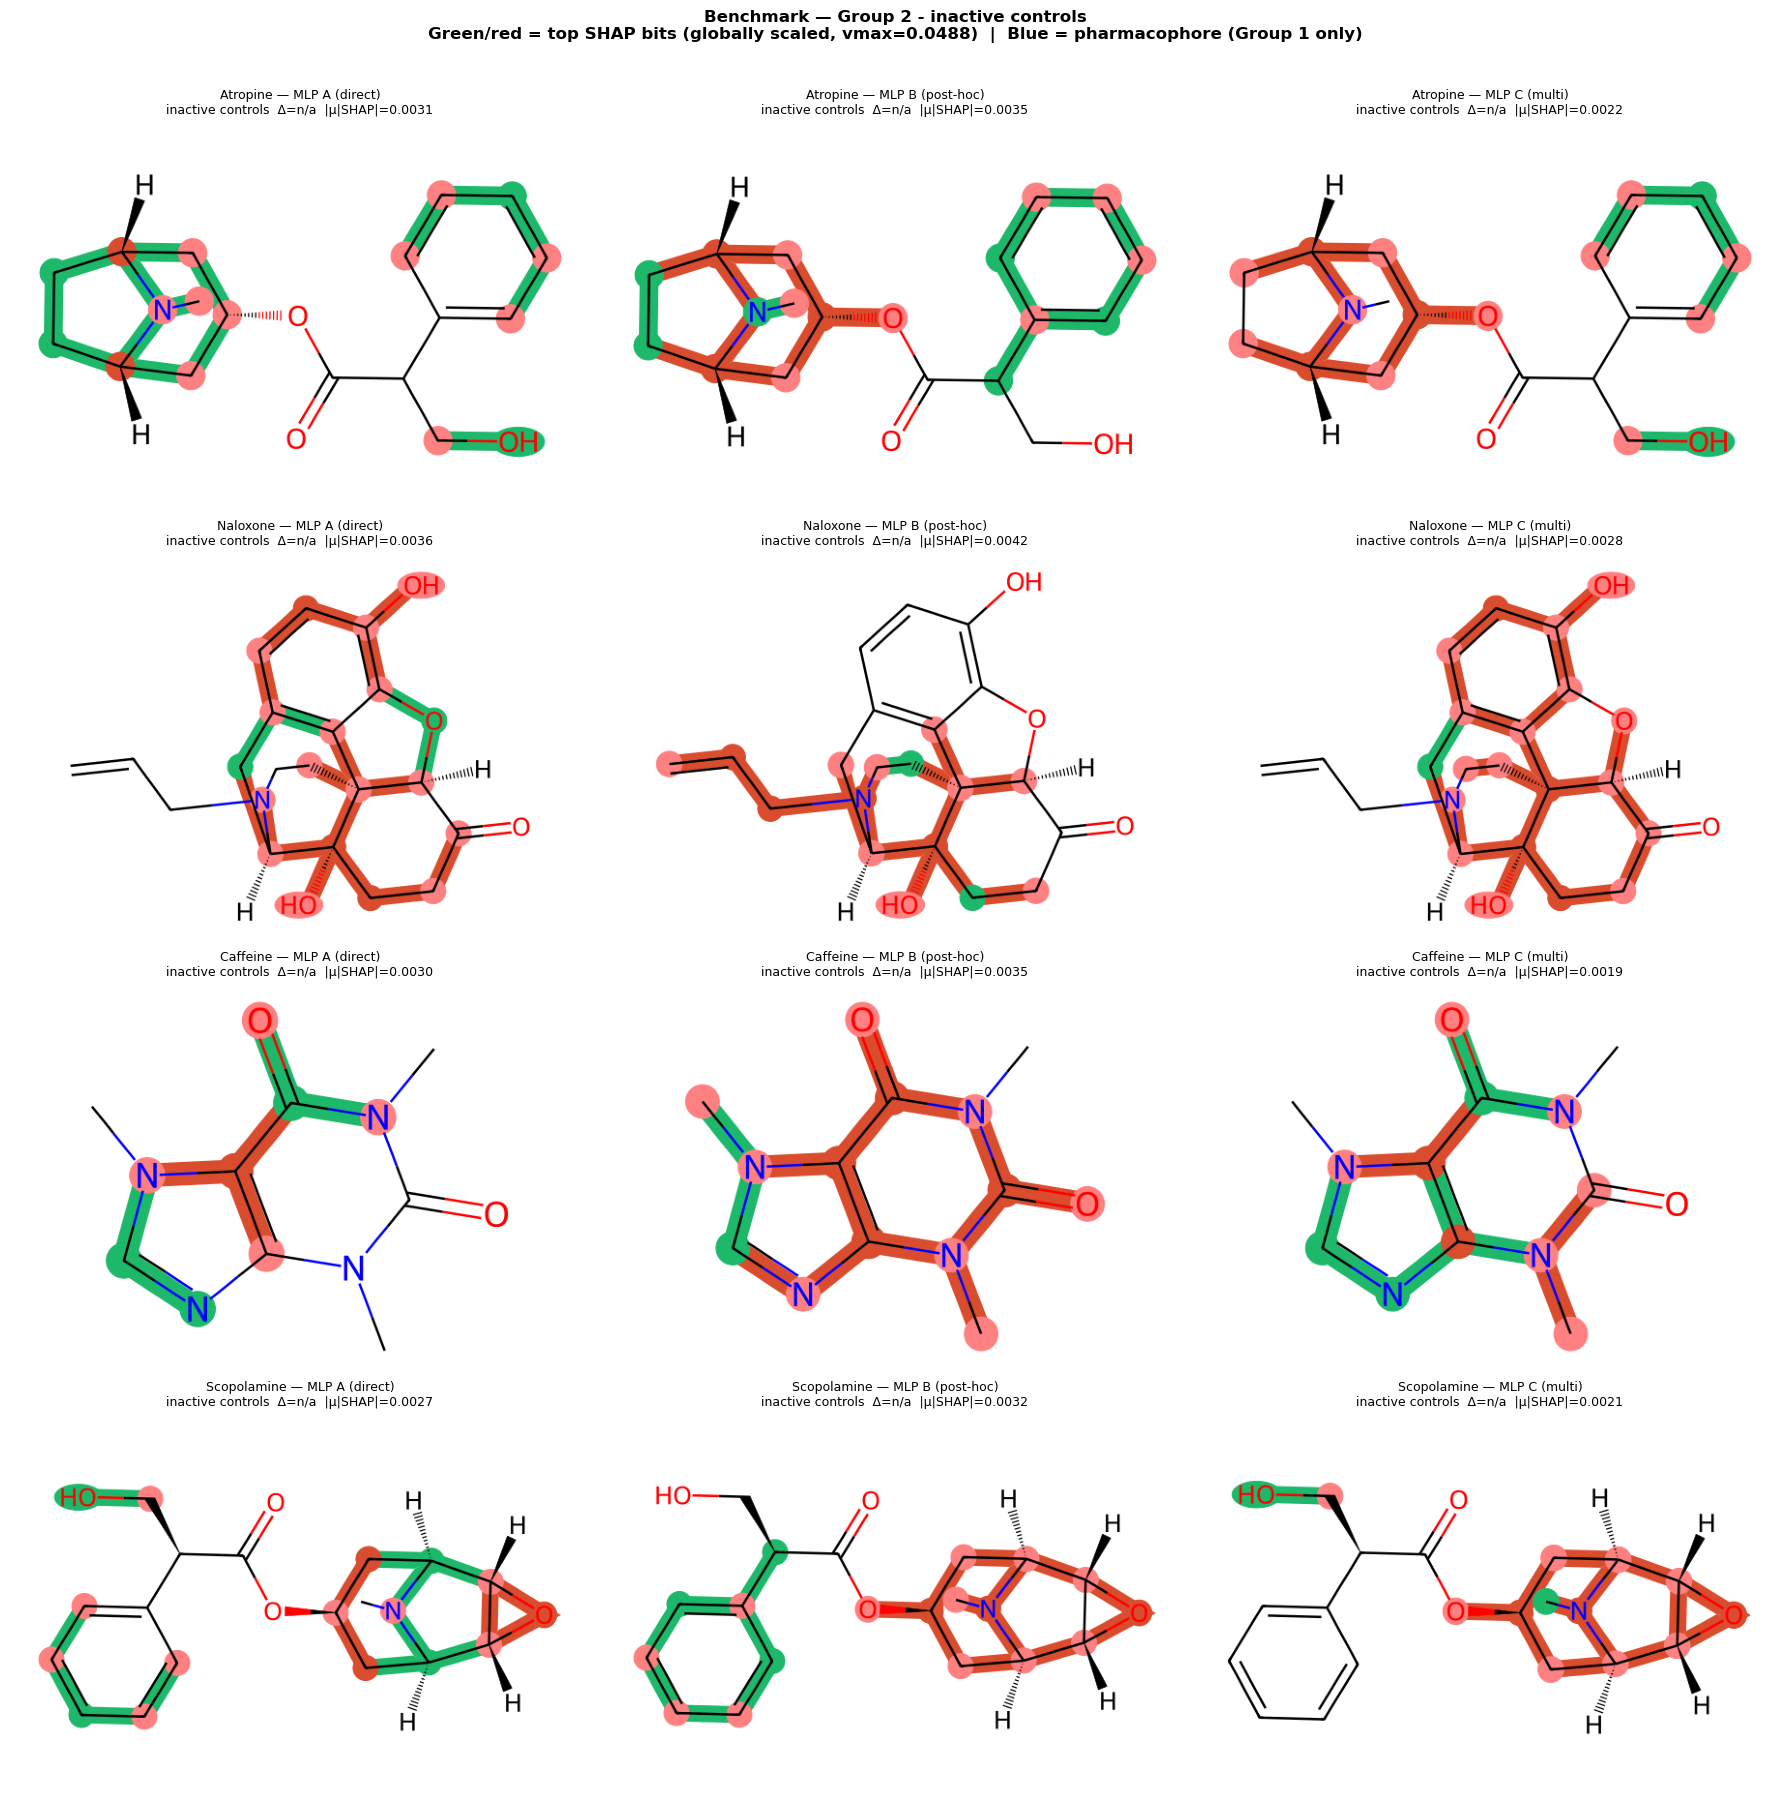

Saved: fig_04_group_2__inactive_controls.png


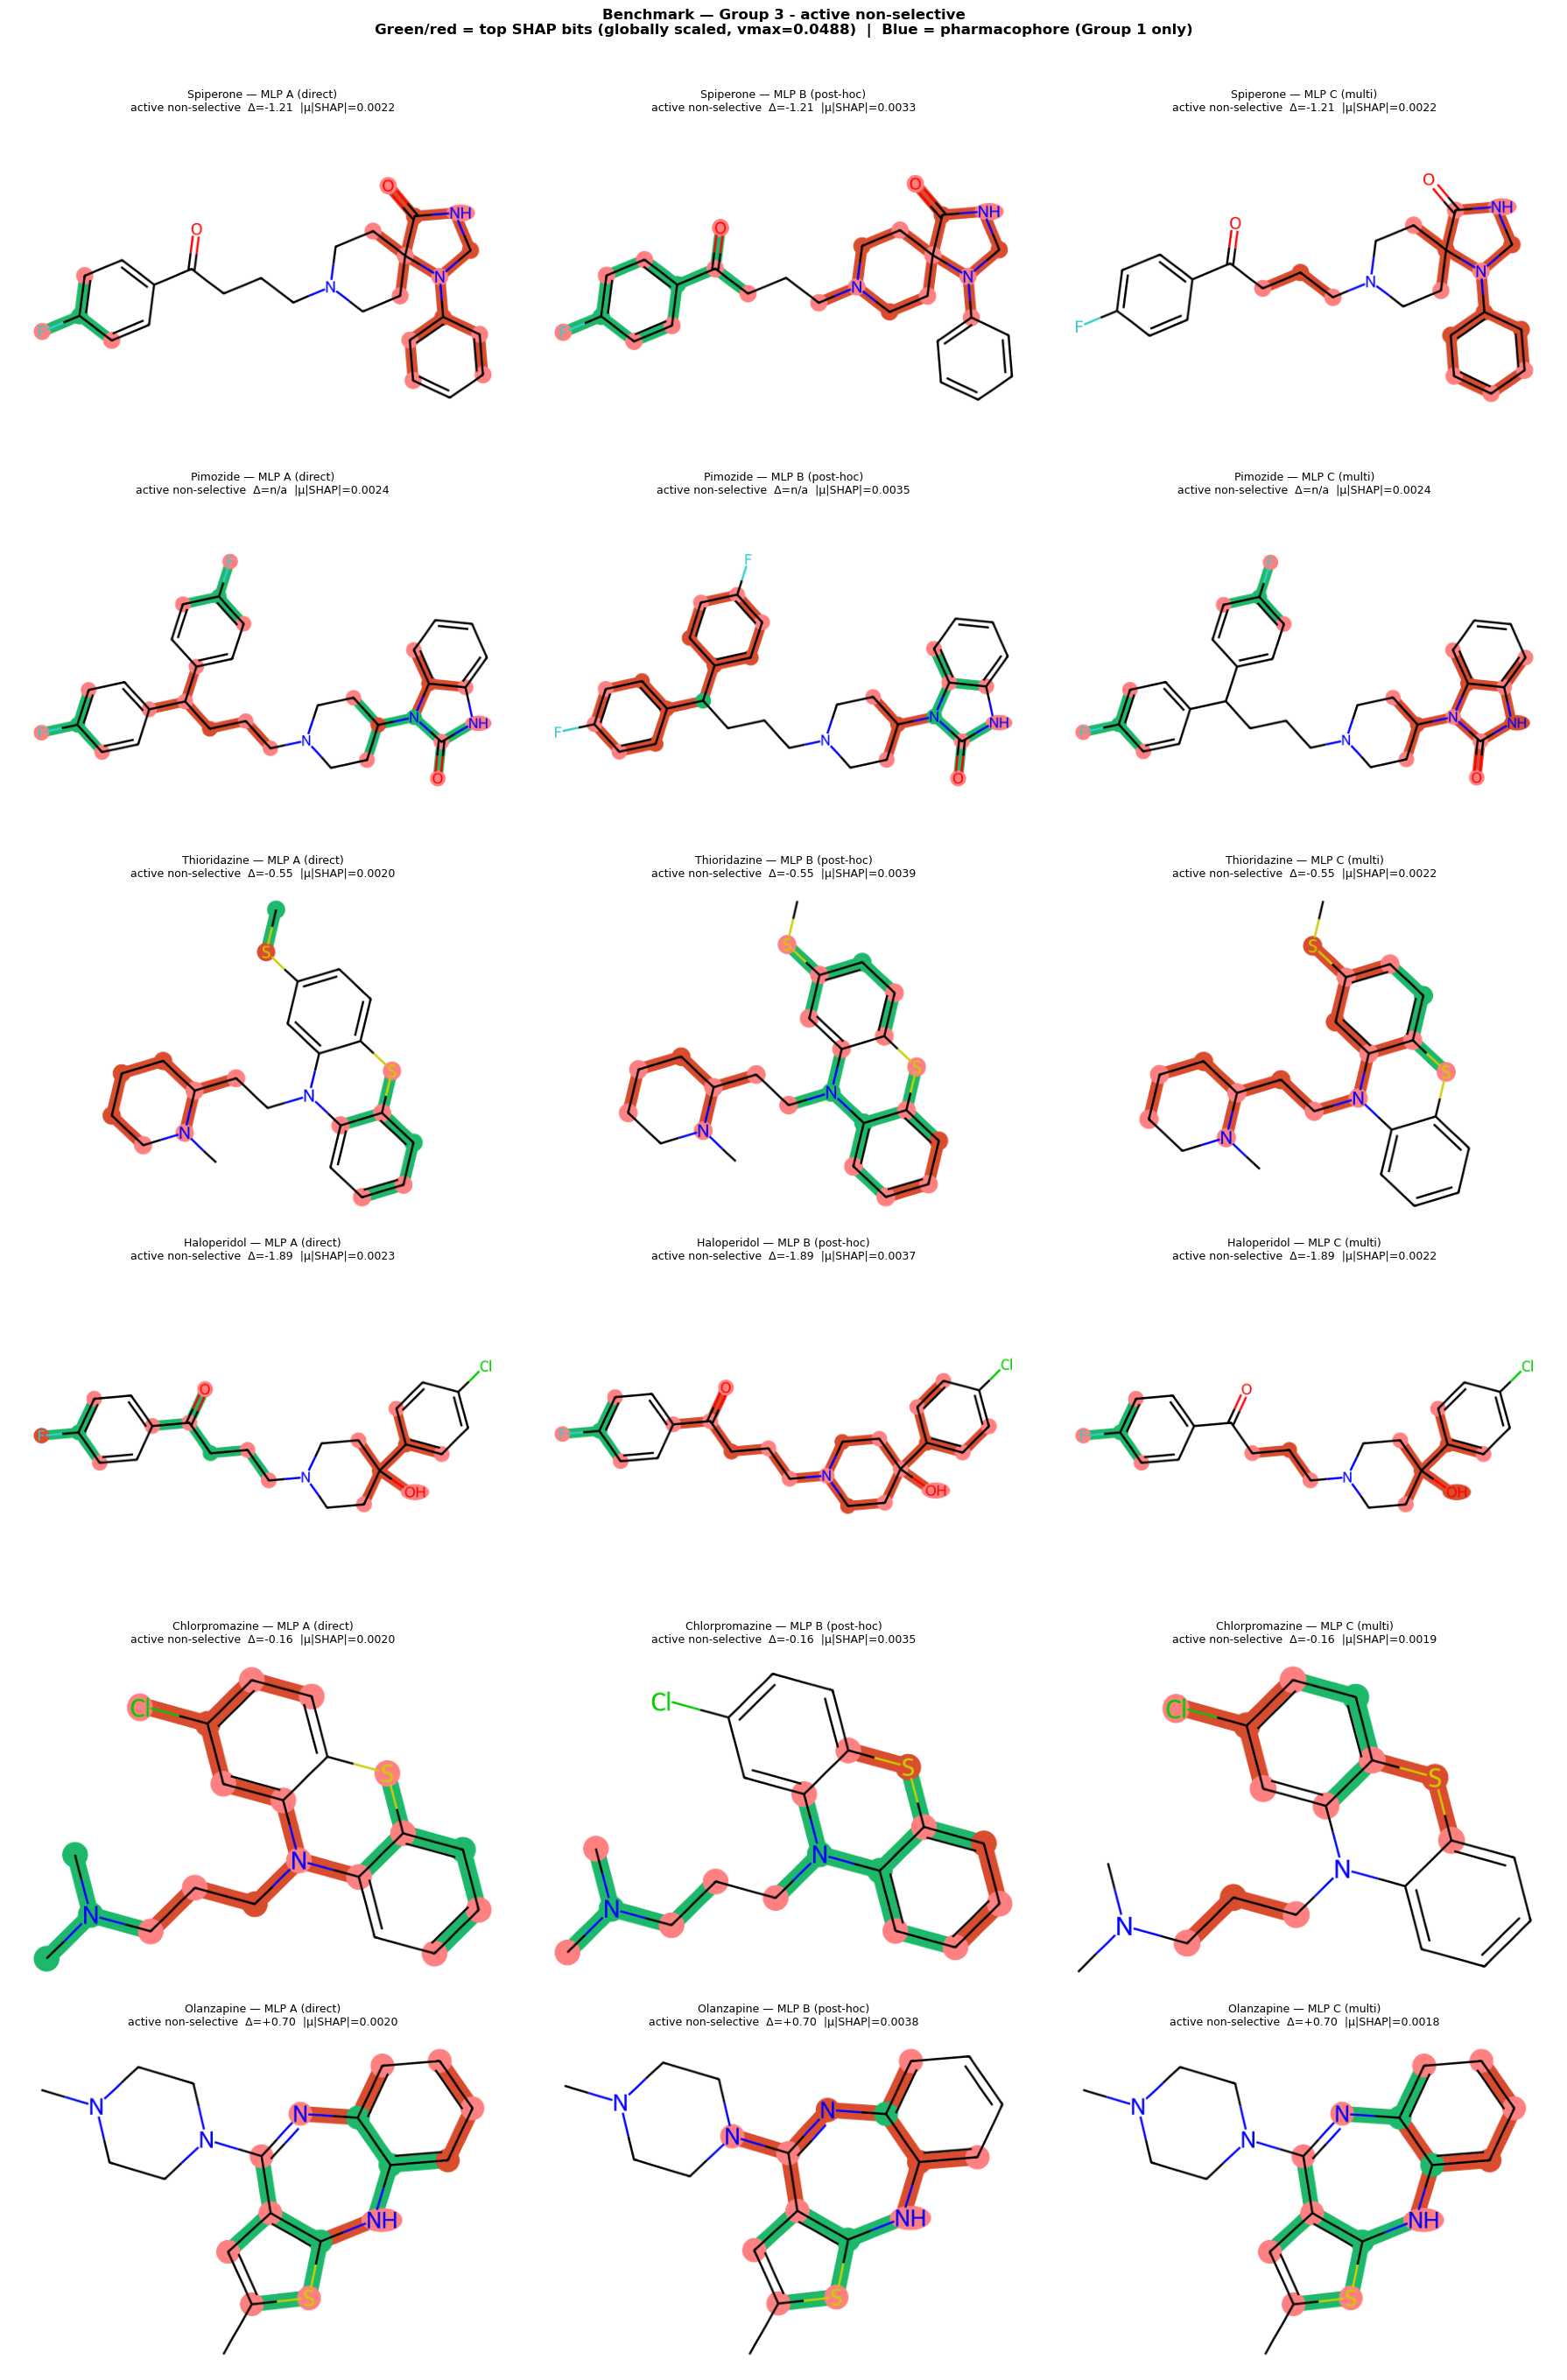

Saved: fig_04_group_3__active_nonselective.png


In [55]:
# ── Global colour scale ───────────────────────────────────────────────────────
# Per-molecule normalisation stretches even noise to full saturation, making
# inactive controls look as intense as selective compounds. A shared vmax
# across all benchmark compounds and approaches fixes this.

all_abs   = np.concatenate([np.abs(shap_mlp_A),
                              np.abs(shap_mlp_B),
                              np.abs(shap_mlp_C)], axis=0)
global_vmax = float(np.percentile(all_abs, 99))
print(f"Global vmax (99th percentile |SHAP|): {global_vmax:.5f}")

# Per-compound mean |SHAP| — lets us see whether G2 controls are genuinely quiet
mean_abs = {}
for label, sv in [('MLP A', shap_mlp_A), ('MLP B', shap_mlp_B), ('MLP C', shap_mlp_C)]:
    for j, row in bench_ok.iterrows():
        key = (row['pref_name'], label)
        mean_abs[key] = float(np.abs(sv[j]).mean())

print("\nMean |SHAP| per compound (should be lower for G2 inactive controls):")
print(f"{'Compound':20s} | {'Group':30s} | {'MLP A':>8s} | {'MLP B':>8s} | {'MLP C':>8s}")
print("-"*80)
for _, row in bench_ok.iterrows():
    name = row['pref_name']
    grp  = row['group'][:28]
    a    = mean_abs.get((name, 'MLP A'), 0)
    b    = mean_abs.get((name, 'MLP B'), 0)
    c    = mean_abs.get((name, 'MLP C'), 0)
    flag = " ← LOUD" if (a > global_vmax * 0.3 and 'inactive' in row['group']) else ""
    print(f"  {name:18s} | {grp:28s} | {a:>8.5f} | {b:>8.5f} | {c:>8.5f}{flag}")


def draw_with_pharma(smi, shap_vec, smarts, vmax=None, top_n=5, size=(600, 400)):
    """
    Highlight top-N active SHAP bits using a GLOBAL vmax for colour intensity.
    Colour saturation = |SHAP| / vmax, capped at 1.0.
    This means truly small attributions appear pale, not bright.
    Blue overlay = pharmacophore SMARTS match.
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    bi = {}
    rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, 2, nBits=N_FP, bitInfo=bi)
    active = set(bi.keys())

    ranked = sorted(active, key=lambda b: abs(float(shap_vec[b])), reverse=True)[:top_n]
    h_atoms, h_bonds = set(), set()
    a_cols, b_cols   = {}, {}

    for bit in ranked:
        sv_val  = float(shap_vec[bit])
        alpha   = min(abs(sv_val) / vmax, 1.0) if vmax else 1.0
        if sv_val > 0:
            col = (1 - 0.88 * alpha, 1 - 0.28 * alpha, 1 - 0.58 * alpha)  # green fades to white
        else:
            col = (1 - 0.15 * alpha, 1 - 0.70 * alpha, 1 - 0.82 * alpha)  # red fades to white

        for atom_idx, radius in bi[bit]:
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
            for bond_idx in env:
                bond = mol.GetBondWithIdx(bond_idx)
                h_bonds.add(bond_idx); b_cols[bond_idx] = col
                h_atoms.add(bond.GetBeginAtomIdx()); h_atoms.add(bond.GetEndAtomIdx())
            a_cols[atom_idx] = col

    # Blue pharmacophore overlay (fixed, not scaled)
    if smarts:
        pat     = Chem.MolFromSmarts(smarts)
        matches = mol.GetSubstructMatches(pat) if pat else []
        for match in matches:
            for a in match:
                a_cols[a] = (0.18, 0.42, 0.82)
                h_atoms.add(a)

    drawer = rdMolDraw2D.MolDraw2DCairo(*size)
    opts   = drawer.drawOptions()
    opts.addAtomIndices = False; opts.bondLineWidth = 2.5
    opts.atomHighlightsAreCircles = False
    try:
        drawer.DrawMolecule(mol, highlightAtoms=list(h_atoms),
                            highlightBonds=list(h_bonds),
                            highlightAtomColors=a_cols, highlightBondColors=b_cols)
        drawer.FinishDrawing()
        return Image.open(io.BytesIO(drawer.GetDrawingText()))
    except:
        return None


# ── Draw all groups with global scale ─────────────────────────────────────────
groups = {
    'Group 1 - 5HT2A selective':  bench_ok[bench_ok['group'].str.contains('5HT2A')],
    'Group 1 - D2 selective':     bench_ok[bench_ok['group'].str.contains('D2')],
    'Group 2 - inactive controls':bench_ok[bench_ok['group'].str.contains('inactive')],
    'Group 3 - active non-selective': bench_ok[bench_ok['group'].str.contains('non-selective')],
}

approach_data = [('MLP A (direct)',   shap_mlp_A),
                 ('MLP B (post-hoc)', shap_mlp_B),
                 ('MLP C (multi)',    shap_mlp_C)]

for group_name, group_df in groups.items():
    n = len(group_df)
    if n == 0: continue
    fig, axes = plt.subplots(n, 3, figsize=(18, 4.5 * n))
    if n == 1: axes = axes.reshape(1, -1)
    fig.suptitle(f"Benchmark — {group_name}\n"
                 f"Green/red = top SHAP bits (globally scaled, vmax={global_vmax:.4f})  |  "
                 f"Blue = pharmacophore (Group 1 only)",
                 fontsize=12, fontweight='bold', y=1.01)

    for row_i, (_, row) in enumerate(group_df.iterrows()):
        name    = row['pref_name']
        smi     = row['canonical_smiles']
        smarts  = PHARMA_SMARTS.get(name)
        delta   = row['delta_pchembl']
        d_str   = f"Δ={delta:+.2f}" if pd.notna(delta) else "Δ=n/a"
        bench_j = bench_ok[bench_ok['pref_name'] == name].index[0]
        grp_lbl = ('5HT2A selective' if 'HT2A' in row['group']
                   else 'D2 selective' if 'D2' in row['group']
                   else row['group'].replace('Group 1 - ','').replace('Group 2 - ','').replace('Group 3 - ',''))

        for col_i, (label, sv) in enumerate(approach_data):
            ax      = axes[row_i, col_i]
            mag     = mean_abs.get((name, label.split()[0] + ' ' + label.split()[1]), 0)
            img     = draw_with_pharma(smi, sv[bench_j], smarts,
                                       vmax=global_vmax, top_n=5)
            if img: ax.imshow(img)
            ax.axis('off')
            ax.set_title(f"{name.capitalize()} — {label}\n"
                         f"{grp_lbl}  {d_str}  |μ|SHAP|={mag:.4f}",
                         fontsize=9)

    plt.tight_layout()
    fname = f"fig_04_{group_name.replace(' ','_').replace('-','').lower()[:40]}.png"
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

## 11. Save

In [56]:
# ── SHAP efficiency and absolute magnitude diagnostic ─────────────────────────
# SHAP efficiency axiom (TreeSHAP, interventional):
#   sum(phi_i) = f(x) - E[f(x)]
# SHAP values are already in ΔpChEMBL units.
# A bit with phi=0.3 contributes 0.3 units to the prediction — comparable
# across ALL compounds without any per-compound normalisation.
#
# Mean |SHAP| over all 2048 bits is meaningless (dominated by zero bits).
# The right comparison is top-k SHAP values in ΔpChEMBL units.

# ── 1. Verify efficiency axiom for TreeSHAP ───────────────────────────────────
print("Efficiency check: sum(SHAP) ≈ prediction − E[f(x)]")
print("(E[f(x)] = mean prediction over 200 background compounds)")
baseline_A = float(tree_A.predict(bg_ov).mean())
print(f"Baseline (Tree A expected value over background): {baseline_A:.4f}")
print()
print(f"{'Compound':20s} | {'pred−base':>10s} | {'sum(SHAP)':>10s} | {'error':>8s}")
print("-"*55)
for j, row in bench_ok.iterrows():
    pred   = bench_ok.loc[j, 'pred_tree_A']
    target = pred - baseline_A
    sv_sum = shap_tree_A[j].sum()
    print(f"  {row['pref_name']:18s} | {target:>10.4f} | {sv_sum:>10.4f} | {abs(target-sv_sum):>8.5f}")

# ── 2. Top-k SHAP values in ΔpChEMBL units ───────────────────────────────────
print()
print("Top-5 SHAP values (ΔpChEMBL units, MLP A GradientSHAP):")
print("Threshold: |phi| ≥ 0.1 ΔpChEMBL = pharmacologically meaningful")
print()
print(f"{'Compound':20s} | {'Group':15s} | {'Pred Δ':>8s} | {'Top-5 phi (ΔpChEMBL)':>40s} | {'n≥0.1'}")
print("-"*105)

thresh  = 0.1
records = []
for j, row in bench_ok.iterrows():
    name   = row['pref_name']
    grp    = group_labels[name]
    pred   = float(bench_ok.loc[j, 'pred_mlp_A'])
    sv     = shap_mlp_A[j]
    top5   = np.sort(np.abs(sv))[::-1][:5]
    n_sig  = int((np.abs(sv) >= thresh).sum())
    records.append({'name': name, 'group': grp, 'pred': pred,
                    'top1': top5[0], 'top5_mean': top5.mean(), 'n_sig': n_sig})
    top5_str = "  ".join([f"{v:.3f}" for v in top5])
    print(f"  {name:18s} | {grp:15s} | {pred:>+8.3f} | {top5_str:>40s} | {n_sig:>5d}")

rec_df2 = pd.DataFrame(records)
print()
print("Group summary — top-1 |SHAP| and n_bits ≥ 0.1 ΔpChEMBL:")
print(rec_df2.groupby('group')[['top1','top5_mean','n_sig']].mean().round(3))

# ── 3. Distribution plot — top-5 in ΔpChEMBL units ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

group_order = ['G1 5HT2A', 'G1 D2', 'G3 non-sel', 'G2 inactive']
cols_g = {'G1 5HT2A':'#1D9E75','G1 D2':'#D85A30',
          'G2 inactive':'#94A3B8','G3 non-sel':'#534AB7'}

# Left: top-1 SHAP per compound, coloured by group
ax = axes[0]
for grp in group_order:
    sub = rec_df2[rec_df2['group']==grp]
    ax.scatter(sub['pred'].abs(), sub['top1'],
               color=cols_g[grp], s=80, label=grp,
               edgecolors='black', linewidths=0.5, zorder=3)
ax.axhline(thresh, color='black', lw=1.5, linestyle='--',
           label=f'|φ|={thresh} ΔpChEMBL threshold')
ax.set(xlabel='|Predicted ΔpChEMBL|', ylabel='Top-1 |SHAP| (ΔpChEMBL units)',
       title='Top bit attribution vs prediction magnitude')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Right: n bits exceeding threshold by group
ax = axes[1]
for xi, grp in enumerate(group_order):
    sub = rec_df2[rec_df2['group']==grp]
    ax.scatter([xi]*len(sub), sub['n_sig'],
               color=cols_g[grp], s=80,
               edgecolors='black', linewidths=0.5, zorder=3)
    ax.errorbar(xi, sub['n_sig'].mean(), yerr=sub['n_sig'].std(),
                fmt='o', color='black', capsize=5, zorder=4)

ax.set_xticks(range(len(group_order)))
ax.set_xticklabels(group_order, fontsize=10)
ax.set(ylabel=f'Number of bits with |φ| ≥ {thresh} ΔpChEMBL',
       title=f'Bits with pharmacologically meaningful attribution (|φ|≥{thresh})')
ax.grid(alpha=0.3, axis='y')

plt.suptitle('SHAP attribution in ΔpChEMBL units — absolute scale\n'
             'Sum(SHAP) = prediction − baseline by efficiency axiom',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_04_shap_absolute_diagnostic.png', dpi=130, bbox_inches='tight')
plt.show()

Efficiency check: sum(SHAP) ≈ prediction − E[f(x)]
(E[f(x)] = mean prediction over 200 background compounds)
Baseline (Tree A expected value over background): 0.5228

Compound             |  pred−base |  sum(SHAP) |    error
-------------------------------------------------------
  RISPERIDONE        |     1.2164 |     1.3629 |  0.14658
  KETANSERIN         |     1.7360 |     1.7491 |  0.01311
  CLOZAPINE          |     0.8536 |     0.7441 |  0.10947
  VOLINANSERIN       |     2.1240 |     1.6100 |  0.51396
  RACLOPRIDE         |    -0.9476 |    -0.7142 |  0.23340
  SULPIRIDE          |    -1.8182 |    -1.0473 |  0.77086
  AMISULPRIDE        |    -2.0719 |    -1.2412 |  0.83072
  ATROPINE           |    -0.2207 |    -0.1785 |  0.04218
  NALOXONE           |    -1.5114 |    -0.9691 |  0.54229
  CAFFEINE           |    -0.0203 |     0.5132 |  0.53347
  SCOPOLAMINE        |    -0.8204 |    -0.2649 |  0.55546
  SPIPERONE          |    -1.9506 |    -1.8033 |  0.14728
  PIMOZIDE           | 

NameError: name 'group_labels' is not defined

PHARMACOPHORE SMARTS VERIFICATION
Blue = SMARTS-matched atoms | Check these manually against known pharmacophore



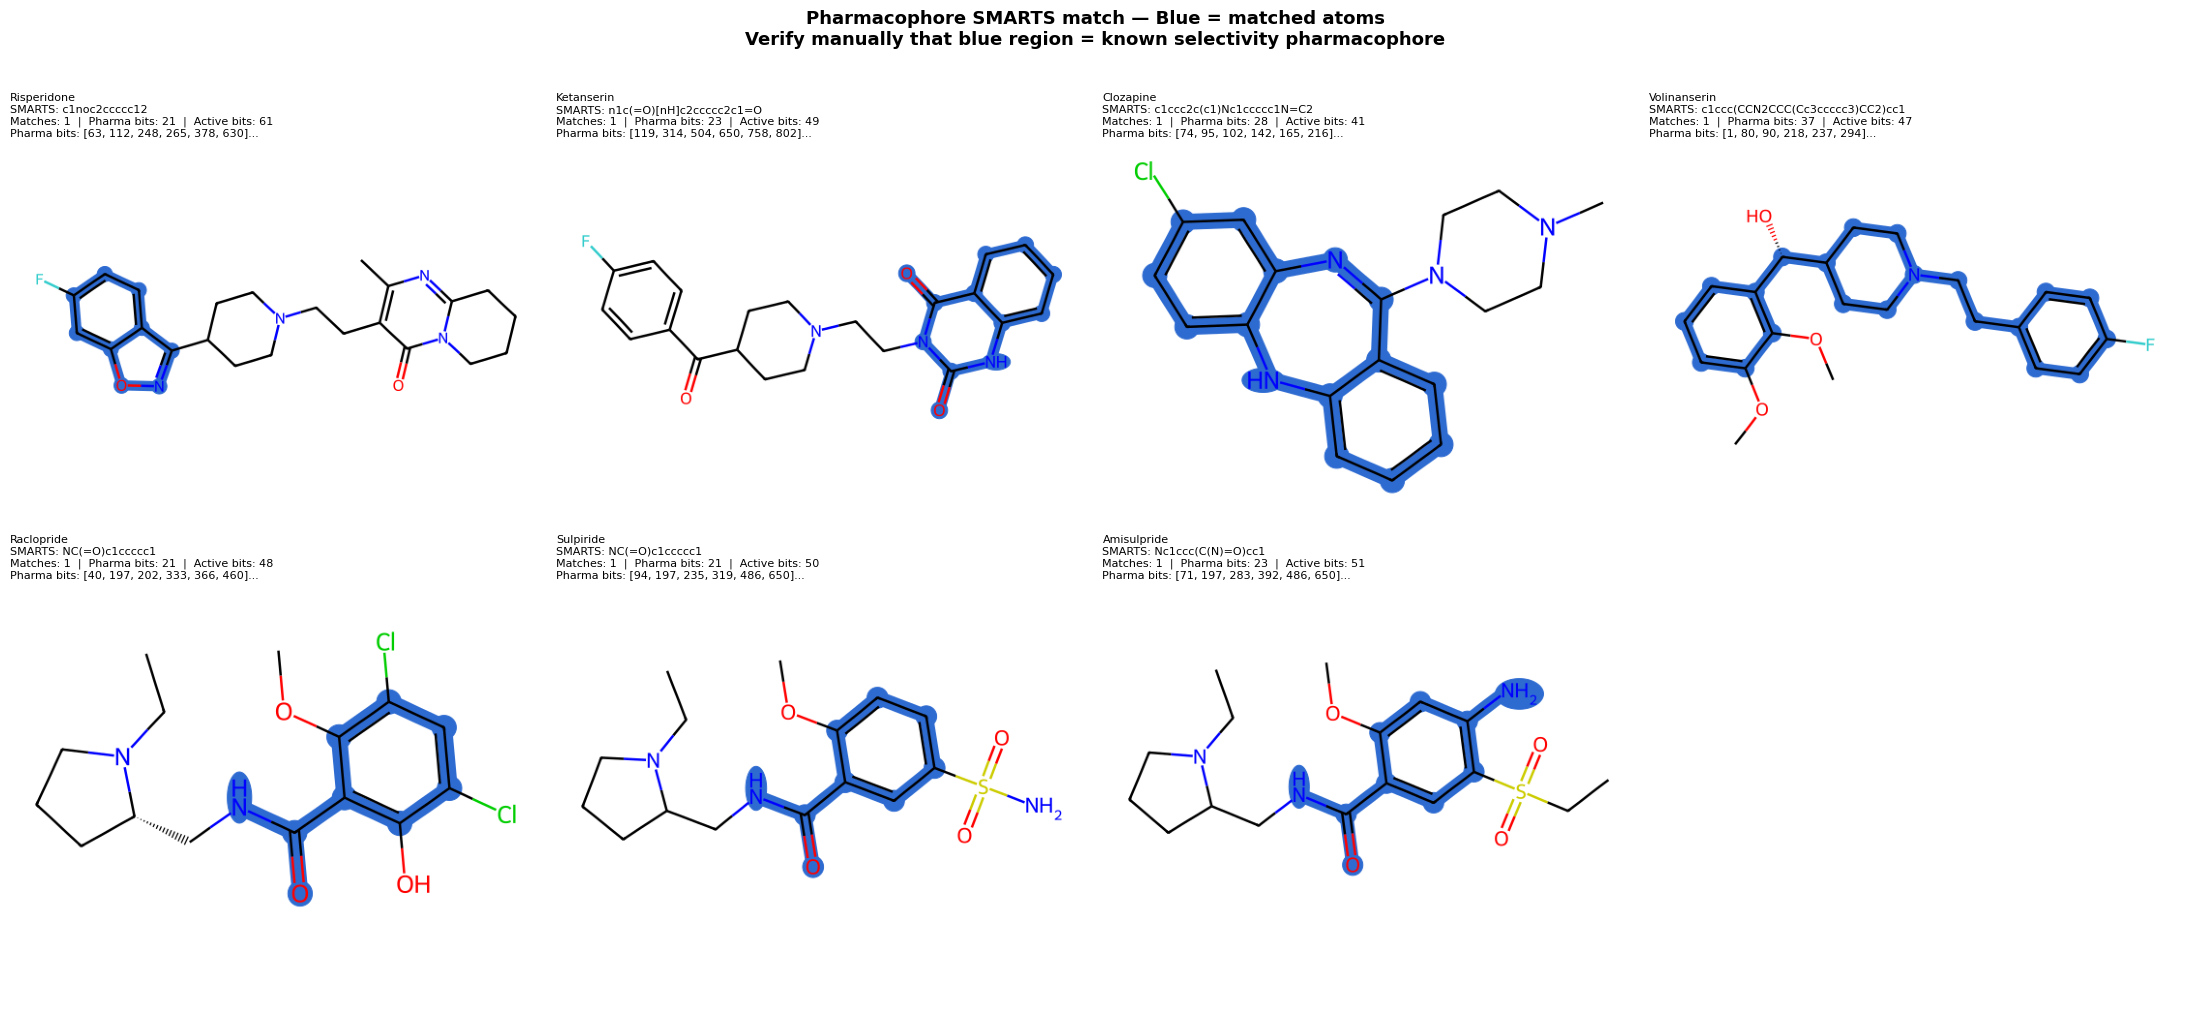

Saved: fig_04_pharma_verification.png

Verify each compound's blue region against literature pharmacophore before proceeding.


In [57]:
# ── A. Pharmacophore SMARTS verification ─────────────────────────────────────
# Draw each Group 1 molecule with ONLY the SMARTS-matched atoms highlighted.
# Check manually: does the blue region match the known pharmacophore?
# Also prints which Morgan bits are in the pharmacophore set.

def draw_pharma_only(smi, smarts, name='', size=(550, 380)):
    """Highlight only the SMARTS-matched atoms in blue. No SHAP."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None, set(), []
    pat = Chem.MolFromSmarts(smarts)
    if pat is None: return None, set(), []

    matches = mol.GetSubstructMatches(pat)
    if not matches:
        print(f"    WARNING: SMARTS did not match {name or 'molecule'}!")
        return None, set(), []

    match_atoms = set(a for match in matches for a in match)

    bi = {}
    rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, 2, nBits=N_FP, bitInfo=bi)
    pharma_bits = {bit for bit, env_list in bi.items()
                   if any(a in match_atoms for a, r in env_list)}

    a_cols, b_cols = {}, {}
    h_atoms, h_bonds = set(match_atoms), set()
    for bond in mol.GetBonds():
        if (bond.GetBeginAtomIdx() in match_atoms and
            bond.GetEndAtomIdx()   in match_atoms):
            h_bonds.add(bond.GetIdx())
            b_cols[bond.GetIdx()] = (0.18, 0.42, 0.82)
    for a in match_atoms:
        a_cols[a] = (0.18, 0.42, 0.82)

    drawer = rdMolDraw2D.MolDraw2DCairo(*size)
    opts = drawer.drawOptions()
    opts.addAtomIndices = False
    opts.bondLineWidth  = 2.5
    opts.atomHighlightsAreCircles = False
    try:
        drawer.DrawMolecule(mol, highlightAtoms=list(h_atoms),
                            highlightBonds=list(h_bonds),
                            highlightAtomColors=a_cols,
                            highlightBondColors=b_cols)
        drawer.FinishDrawing()
        return Image.open(io.BytesIO(drawer.GetDrawingText())), pharma_bits, matches
    except Exception as e:
        print(f"  Draw error: {e}")
        return None, pharma_bits, matches

g1_bench = bench_ok[bench_ok['group'].str.startswith('Group 1')].reset_index(drop=True)

print("PHARMACOPHORE SMARTS VERIFICATION")
print("Blue = SMARTS-matched atoms | Check these manually against known pharmacophore")
print()

n = len(g1_bench)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, row in g1_bench.iterrows():
    name   = row['pref_name']
    smi    = row['canonical_smiles']
    smarts = PHARMA_SMARTS.get(name)
    ax     = axes[idx]

    if smarts is None:
        ax.text(0.5, 0.5, f"{name}\nNo SMARTS defined",
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.axis('off')
        continue

    img, p_bits, matches = draw_pharma_only(smi, smarts, name=name)

    if img:
        ax.imshow(img)
    ax.axis('off')

    active_bits = get_active_bits(smi)
    ax.set_title(
        f"{name.capitalize()}\n"
        f"SMARTS: {smarts[:35]}{'...' if len(smarts)>35 else ''}\n"
        f"Matches: {len(matches)}  |  Pharma bits: {len(p_bits)}  |  Active bits: {len(active_bits)}\n"
        f"Pharma bits: {sorted(p_bits)[:6]}{'...' if len(p_bits)>6 else ''}",
        fontsize=8, loc='left'
    )

# Hide unused axes
for ax in axes[n:]:
    ax.axis('off')

plt.suptitle("Pharmacophore SMARTS match — Blue = matched atoms\n"
             "Verify manually that blue region = known selectivity pharmacophore",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_04_pharma_verification.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: fig_04_pharma_verification.png")
print("\nVerify each compound's blue region against literature pharmacophore before proceeding.")

Pharmacophore recall — Group 1 compounds
Compound           |  n_p |    Tre @5   Tre@10 |    Tre @5   Tre@10 |    MLP @5   MLP@10 |    MLP @5   MLP@10 |    MLP @5   MLP@10 | 
-----------------------------------------------------------------------------------------------
  RISPERIDONE      |   19 |   0.00   0.16 |   0.05   0.26 |   0.05   0.16 |   0.11   0.16 |   0.05   0.16 | 
  KETANSERIN       |   17 |   0.18   0.35 |   0.15   0.20 |   0.12   0.24 |   0.10   0.25 |   0.18   0.35 | 
  CLOZAPINE        |   21 |   0.19   0.33 |   0.20   0.36 |   0.24   0.38 |   0.20   0.36 |   0.24   0.38 | 
  VOLINANSERIN     |   29 |   0.17   0.31 |   0.12   0.27 |   0.14   0.28 |   0.09   0.24 |   0.14   0.31 | 
  RACLOPRIDE       |   12 |   0.17   0.25 |   0.06   0.12 |   0.17   0.33 |   0.12   0.12 |   0.25   0.25 | 
  SULPIRIDE        |   16 |   0.06   0.31 |   0.00   0.11 |   0.06   0.19 |   0.00   0.17 |   0.06   0.19 | 
  AMISULPRIDE      |   16 |   0.06   0.25 |   0.00   0.12 |   0.06   0.25 |

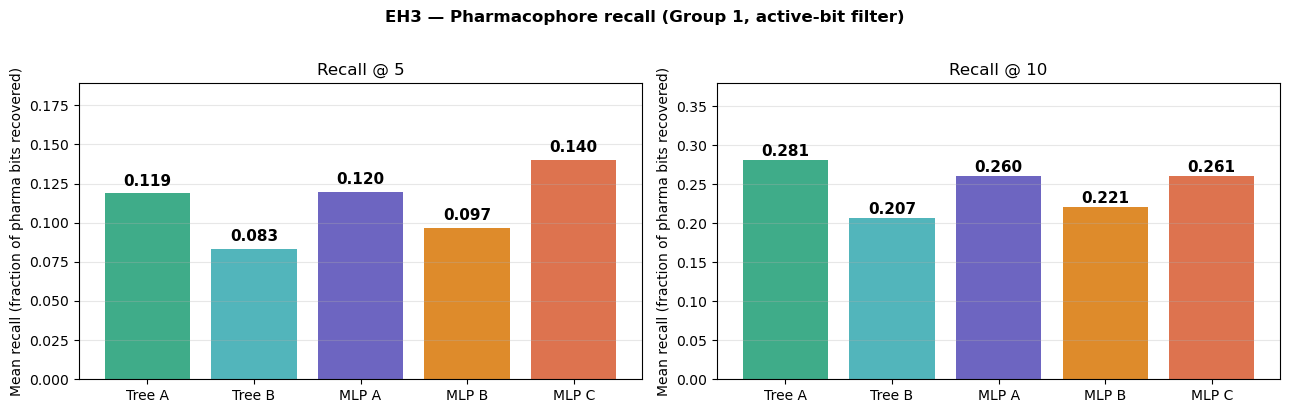

In [58]:
# ── B. Pharmacophore recall at k = 5 and k = 10 ──────────────────────────────
# Recall@k = |top-k |SHAP| bits ∩ pharma bits| / |model-visible pharma bits|
# rank_bits = active Morgan bits ∩ model feature mask (excludes zero-SHAP filtered bits)

approach_shap = [
    ('Tree A', shap_tree_A),
    ('Tree B', shap_tree_B),
    ('MLP A',  shap_mlp_A),
    ('MLP B',  shap_mlp_B),
    ('MLP C',  shap_mlp_C),
]

recall_rows = []
for _, row in g1_bench.iterrows():
    name   = row['pref_name']
    smi    = row['canonical_smiles']
    smarts = PHARMA_SMARTS.get(name)
    if smarts is None: continue

    bench_j = bench_ok[bench_ok['pref_name']==name].index[0]
    rec = {'compound': name, 'group': row['group']}
    for label, sv in approach_shap:
        r_bits = get_rank_bits(smi, label)
        p_bits = get_pharma_bits(smi, smarts, label)
        rec['n_pharma'] = len(p_bits)
        rec['n_rank']   = len(r_bits)
        rec[f'{label}@5']  = recall_at_k(sv[bench_j], p_bits, r_bits, k=5)
        rec[f'{label}@10'] = recall_at_k(sv[bench_j], p_bits, r_bits, k=10)
    recall_rows.append(rec)

recall_df = pd.DataFrame(recall_rows)

print("Pharmacophore recall — Group 1 compounds")
print("="*95)
hdr = f"{'Compound':18s} | {'n_p':>4s} | "
for label, _ in approach_shap:
    hdr += f"{'@5':>6s} {'@10':>6s} | ".replace('  @', f' {label[:3]}@')
print(hdr.replace('@5', ' @5').replace('@10', '@10'))
print("-"*95)

for _, r in recall_df.iterrows():
    line = f"  {r['compound']:16s} | {r['n_pharma']:>4.0f} | "
    for label, _ in approach_shap:
        v5  = r.get(f'{label}@5',  np.nan)
        v10 = r.get(f'{label}@10', np.nan)
        line += f"{v5:>6.2f} {v10:>6.2f} | "
    print(line)

print("-"*95)
print(f"  {'Mean':16s} | {'':>4s} | ", end='')
for label, _ in approach_shap:
    v5  = recall_df[f'{label}@5'].mean()
    v10 = recall_df[f'{label}@10'].mean()
    print(f"{v5:>6.3f} {v10:>6.3f} | ", end='')
print()

# Bar chart — mean recall@5 and recall@10 per approach
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels   = [l for l, _ in approach_shap]
cols_app = ['#1D9E75','#34A8B0','#534AB7','#D97706','#D85A30']

for ax, k, title in [(axes[0], 5, 'Recall @ 5'), (axes[1], 10, 'Recall @ 10')]:
    means = [recall_df[f'{l}@{k}'].mean() for l in labels]
    bars  = ax.bar(labels, means, color=cols_app, alpha=0.85, edgecolor='none')
    for bar, val in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
    ax.set(ylabel=f'Mean recall (fraction of pharma bits recovered)',
           title=title, ylim=[0, min(1.0, max(means)*1.35)])
    ax.grid(alpha=0.3, axis='y')
    ax.set_xticklabels(labels, fontsize=10)

plt.suptitle('EH3 — Pharmacophore recall (Group 1, active-bit filter)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_04_recall_bar.png', dpi=130, bbox_inches='tight')
plt.show()

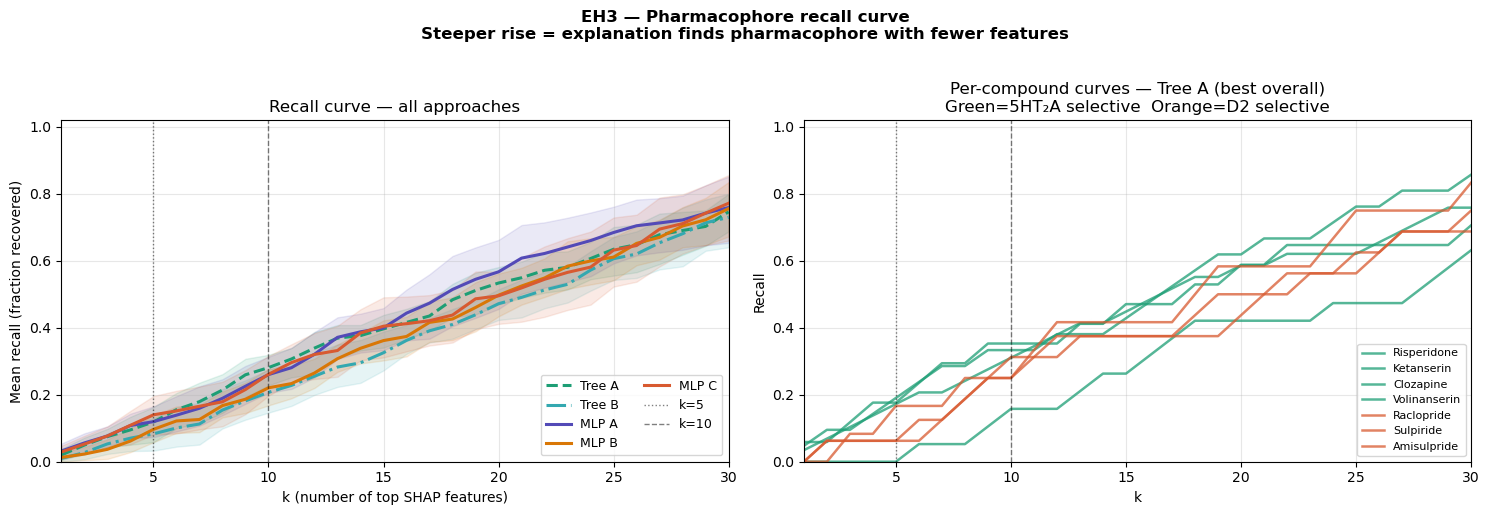


Final recall summary:
Approach   |  Recall@5 |  Recall@10 |   AUC@30
----------------------------------------------
  Tree A     |    0.1187 |     0.2810 |   0.3881
  Tree B     |    0.0832 |     0.2071 |   0.3400
  MLP A      |    0.1197 |     0.2601 |   0.4044
  MLP B      |    0.0966 |     0.2207 |   0.3574
  MLP C      |    0.1400 |     0.2610 |   0.3793


In [59]:
# ── C. Recall curve — % pharmacophore recovered vs k ─────────────────────────
# Shows how quickly each approach recovers the pharmacophore bits
# as we include more SHAP features. Steeper = better.
# Plotted as mean over all Group 1 compounds with bootstrap 95% CI.

K_MAX = 30
k_range = list(range(1, K_MAX + 1))

def recall_curve(shap_mat, bench_df, pharma_smarts, approach, k_range):
    """Mean recall@k over Group 1 using model-visible bit pools."""
    compound_curves = []
    for _, row in bench_df.iterrows():
        name   = row['pref_name']
        smarts = pharma_smarts.get(name)
        if smarts is None: continue
        bench_j = bench_ok[bench_ok['pref_name']==name].index[0]
        r_bits  = get_rank_bits(row['canonical_smiles'], approach)
        p_bits  = get_pharma_bits(row['canonical_smiles'], smarts, approach)
        if not p_bits or not r_bits: continue
        sv = shap_mat[bench_j]
        scores = {b: abs(float(sv[b])) for b in r_bits}
        ranked = sorted(scores, key=scores.get, reverse=True)
        curve = []
        for k in k_range:
            top = set(ranked[:min(k, len(ranked))])
            curve.append(len(top & p_bits) / len(p_bits))
        compound_curves.append(curve)
    if not compound_curves:
        return np.zeros(len(k_range)), np.zeros(len(k_range)), np.zeros(len(k_range))
    arr  = np.array(compound_curves)   # (n_compounds, K_MAX)
    mean = arr.mean(axis=0)
    # Bootstrap CI
    rng_b = np.random.RandomState(SEED)
    boots = []
    for _ in range(500):
        idx = rng_b.choice(len(arr), len(arr), replace=True)
        boots.append(arr[idx].mean(axis=0))
    boots = np.array(boots)
    lo, hi = np.percentile(boots, 2.5, axis=0), np.percentile(boots, 97.5, axis=0)
    return mean, lo, hi

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cols_app  = {'Tree A':'#1D9E75','Tree B':'#34A8B0',
             'MLP A':'#534AB7','MLP B':'#D97706','MLP C':'#D85A30'}
ls_map    = {'Tree A':'--','Tree B':'-.','MLP A':'-','MLP B':'-','MLP C':'-'}

# Left: all approaches on one plot
ax = axes[0]
for label, sv in approach_shap:
    mean, lo, hi = recall_curve(sv, g1_bench, PHARMA_SMARTS, label, k_range)
    col = cols_app[label]
    ax.plot(k_range, mean, color=col, lw=2.2, label=label, linestyle=ls_map[label])
    ax.fill_between(k_range, lo, hi, color=col, alpha=0.12)

ax.axvline(5,  color='black', lw=1, linestyle=':', alpha=0.5, label='k=5')
ax.axvline(10, color='black', lw=1, linestyle='--', alpha=0.5, label='k=10')
ax.set(xlabel='k (number of top SHAP features)', ylabel='Mean recall (fraction recovered)',
       title='Recall curve — all approaches', xlim=[1, K_MAX], ylim=[0, 1.02])
ax.legend(fontsize=9, ncol=2); ax.grid(alpha=0.3)

# Right: per-compound curves for best approach (highest recall@10)
best_label = max(labels, key=lambda l: recall_df[f'{l}@10'].mean())
best_sv    = dict(approach_shap)[best_label]
ax2 = axes[1]
for _, row in g1_bench.iterrows():
    name   = row['pref_name']
    smarts = PHARMA_SMARTS.get(name)
    if smarts is None: continue
    bench_j = bench_ok[bench_ok['pref_name']==name].index[0]
    a_bits  = get_active_bits(row['canonical_smiles'])
    p_bits  = get_pharma_bits(row['canonical_smiles'], smarts)
    if not p_bits: continue
    sv      = best_sv[bench_j]
    ranked  = sorted({b: abs(float(sv[b])) for b in a_bits},
                     key=lambda b: abs(float(sv[b])), reverse=True)
    curve = [len(set(ranked[:k]) & p_bits) / len(p_bits) for k in k_range]
    col   = ('#1D9E75' if '5HT2A' in row['group'] else '#D85A30')
    ax2.plot(k_range, curve, color=col, lw=1.8, alpha=0.75, label=name.capitalize())

ax2.axvline(5,  color='black', lw=1, linestyle=':', alpha=0.5)
ax2.axvline(10, color='black', lw=1, linestyle='--', alpha=0.5)
ax2.set(xlabel='k', ylabel='Recall',
        title=f'Per-compound curves — {best_label} (best overall)\n'
              f'Green=5HT₂A selective  Orange=D2 selective',
        xlim=[1, K_MAX], ylim=[0, 1.02])
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.suptitle('EH3 — Pharmacophore recall curve\n'
             'Steeper rise = explanation finds pharmacophore with fewer features',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_04_recall_curve.png', dpi=130, bbox_inches='tight')
plt.show()

# Summary
print("\nFinal recall summary:")
print(f"{'Approach':10s} | {'Recall@5':>9s} | {'Recall@10':>10s} | {'AUC@30':>8s}")
print("-"*46)
for label, sv in approach_shap:
    mean, _, _ = recall_curve(sv, g1_bench, PHARMA_SMARTS, label, k_range)
    auc = np.trapz(mean, k_range) / K_MAX
    r5  = recall_df[f'{label}@5'].mean()
    r10 = recall_df[f'{label}@10'].mean()
    print(f"  {label:10s} | {r5:>9.4f} | {r10:>10.4f} | {auc:>8.4f}")

In [60]:
rec_df.to_csv('benchmark_recovery.csv', index=False)
bench_ok[['pref_name','group','delta_pchembl',
           'pred_tree_A','pred_mlp_A','pred_mlp_B','pred_mlp_C']].to_csv(
    'benchmark_predictions.csv', index=False)

print("Saved:")
print("  benchmark_recovery.csv    — pharmacophore recovery per compound × approach")
print("  benchmark_predictions.csv — model predictions vs expected ΔpChEMBL")
print()
print("Update slide 9 and 10 in qsar_selectivity.pptx with EH3 results.")

Saved:
  benchmark_recovery.csv    — pharmacophore recovery per compound × approach
  benchmark_predictions.csv — model predictions vs expected ΔpChEMBL

Update slide 9 and 10 in qsar_selectivity.pptx with EH3 results.


Random baseline recall@k (Tree A bit pool, 2,000 draws per compound):
Compound           | n_rank | n_pharma |  E[recall@5] |  E[recall@10] | Analytic@10
-------------------------------------------------------------------------------------
  RISPERIDONE      |     52 |       19 | 0.0953 [0.0000,0.2105] | 0.1900 [0.0526,0.3158] | 0.1923
  KETANSERIN       |     39 |       17 | 0.1281 [0.0000,0.2353] | 0.2566 [0.1176,0.4118] | 0.2564
  CLOZAPINE        |     34 |       21 | 0.1460 [0.0476,0.2381] | 0.2953 [0.1905,0.4286] | 0.2941
  VOLINANSERIN     |     38 |       29 | 0.1311 [0.0690,0.1724] | 0.2627 [0.1724,0.3448] | 0.2632
  RACLOPRIDE       |     33 |       12 | 0.1512 [0.0000,0.3333] | 0.3034 [0.0833,0.5000] | 0.3030
  SULPIRIDE        |     38 |       16 | 0.1287 [0.0000,0.2500] | 0.2631 [0.1250,0.4375] | 0.2632
  AMISULPRIDE      |     37 |       16 | 0.1373 [0.0000,0.2500] | 0.2742 [0.1250,0.4375] | 0.2703

  Mean random recall@5:  0.1311 ± 0.0181
  Mean random recall@10: 0.2636 

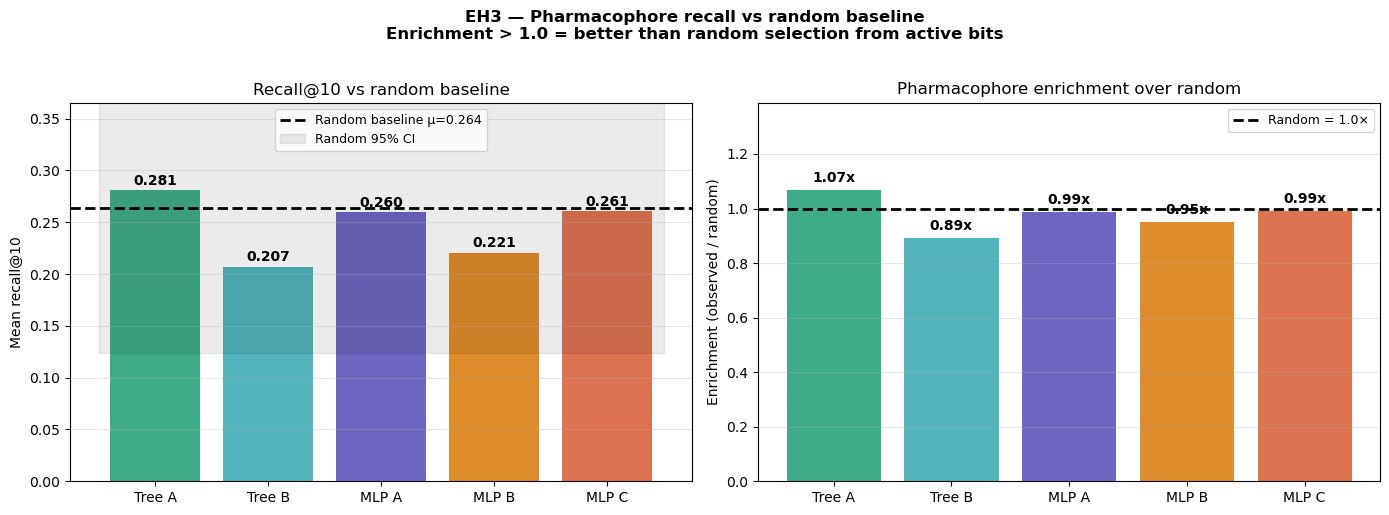

In [61]:
# ── Random baseline and enrichment ───────────────────────────────────────────
# Without a random baseline, recall@k cannot be interpreted.
# Expected recall@k (random) = k / |active_bits| per compound
# Enrichment = observed recall@k / expected recall@k (random)
#
# Also runs Wilcoxon signed-rank on per-compound recall pairs.

from scipy.stats import wilcoxon

N_BOOT_BASE = 2000   # bootstrap resamples for random baseline CI


def random_baseline_recall(rank_bits, pharma_bits, k,
                           n_boot=N_BOOT_BASE, seed=SEED):
    """Bootstrap E[recall@k] when k bits are drawn uniformly from rank_bits."""
    if not pharma_bits or not rank_bits:
        return np.nan, np.nan, np.nan, np.nan
    rank_list = sorted(rank_bits)
    k = min(k, len(rank_list))
    rng = np.random.RandomState(seed)
    recs = []
    for _ in range(n_boot):
        sample = set(rng.choice(rank_list, size=k, replace=False))
        recs.append(len(sample & pharma_bits) / len(pharma_bits))
    recs = np.asarray(recs)
    return recs.mean(), recs.std(), np.percentile(recs, 2.5), np.percentile(recs, 97.5)


# ── 1. Per-compound random baseline ──────────────────────────────────────────

print("Random baseline recall@k (Tree A bit pool, 2,000 draws per compound):")
print(
    f"{'Compound':18s} | {'n_rank':>6s} | {'n_pharma':>8s} | "
    f"{'E[recall@5]':>12s} | {'E[recall@10]':>13s} | {'Analytic@10'}"
)
print("-" * 85)

baseline_records = []

for _, row in g1_bench.iterrows():
    name = row["pref_name"]
    smi  = row["canonical_smiles"]
    smarts = PHARMA_SMARTS.get(name)
    if smarts is None:
        continue

    r_bits = get_rank_bits(smi, 'Tree A')
    p_bits = get_pharma_bits(smi, smarts, 'Tree A')
    if not p_bits:
        continue

    m5, s5, lo5, hi5   = random_baseline_recall(r_bits, p_bits, k=5)
    m10, s10, lo10, hi10 = random_baseline_recall(r_bits, p_bits, k=10)
    analytic10 = expected_random_recall(10, r_bits)

    baseline_records.append({
        "compound": name, "n_rank": len(r_bits), "n_pharma": len(p_bits),
        "rand@5": m5, "rand@5_lo": lo5, "rand@5_hi": hi5,
        "rand@10": m10, "rand@10_lo": lo10, "rand@10_hi": hi10,
    })

    print(
        f"  {name:16s} | {len(r_bits):>6d} | {len(p_bits):>8d} | "
        f"{m5:.4f} [{lo5:.4f},{hi5:.4f}] | "
        f"{m10:.4f} [{lo10:.4f},{hi10:.4f}] | {analytic10:.4f}"
    )

base_df = pd.DataFrame(baseline_records)

print(
    f"\n  Mean random recall@5:  "
    f"{base_df['rand@5'].mean():.4f} ± "
    f"{base_df['rand@5'].std():.4f}"
)

print(
    f"  Mean random recall@10: "
    f"{base_df['rand@10'].mean():.4f} ± "
    f"{base_df['rand@10'].std():.4f}"
)


# ── 2. Enrichment = observed / random ────────────────────────────────────────

print(
    "\nEnrichment = observed recall / random recall baseline "
    "(>1 = better than random)"
)

print(
    f"{'Approach':10s} | "
    f"{'Recall@10':>10s} | "
    f"{'Random@10':>10s} | "
    f"{'Enrichment':>11s} | "
    f"Interpretation"
)

print("-" * 70)

enr_records = {}

for label, sv in approach_shap:
    obs_per_cpd = []
    rnd_per_cpd = []

    for _, row in g1_bench.iterrows():
        name = row["pref_name"]
        smarts = PHARMA_SMARTS.get(name)
        if smarts is None:
            continue

        bench_j = bench_ok[bench_ok["pref_name"] == name].index[0]
        r_bits = get_rank_bits(row["canonical_smiles"], label)
        p_bits = get_pharma_bits(row["canonical_smiles"], smarts, label)
        if not p_bits or not r_bits:
            continue

        obs = recall_at_k(sv[bench_j], p_bits, r_bits, k=10)
        rnd = expected_random_recall(10, r_bits)
        obs_per_cpd.append(obs)
        rnd_per_cpd.append(rnd)

    obs_mean = np.mean(obs_per_cpd)
    rnd_mean = np.mean(rnd_per_cpd)

    enr = (
        obs_mean / rnd_mean
        if rnd_mean > 0
        else np.nan
    )

    enr_records[label] = {
        "obs": obs_per_cpd,
        "rnd": rnd_per_cpd,
        "enrichment": enr,
    }

    interp = (
        ">> random"
        if enr > 2
        else "> random"
        if enr > 1.3
        else "≈ random"
        if enr > 0.9
        else "< random"
    )

    print(
        f"  {label:10s} | "
        f"{obs_mean:>10.4f} | "
        f"{rnd_mean:>10.4f} | "
        f"{enr:>11.3f}x | "
        f"{interp}"
    )


# ── 3. Wilcoxon signed-rank ──────────────────────────────────────────────────

print(
    "\nWilcoxon signed-rank "
    "(paired, per compound, recall@10)"
)

print(
    f"n={len(g1_bench)} compounds "
    "— VERY LOW POWER, treat as indicative only"
)

print(
    f"{'Comparison':15s} | "
    f"{'p-value':>10s} | "
    f"{'A mean':>8s} | "
    f"{'B mean':>8s} | "
    f"{'Δ mean'}"
)

print("-" * 60)

pairs = [
    ("MLP A", "MLP B"),
    ("MLP A", "MLP C"),
    ("Tree A", "Tree B"),
]

for lA, lB in pairs:

    dA = enr_records.get(lA, {}).get("obs", [])
    dB = enr_records.get(lB, {}).get("obs", [])

    if len(dA) < 2:
        continue

    diffs = [a - b for a, b in zip(dA, dB)]

    if all(d == 0 for d in diffs):
        print(
            f"  {lA} vs {lB}: "
            "all differences zero — cannot test"
        )
        continue

    try:
        stat, p = wilcoxon(
            dA,
            dB,
            alternative="two-sided"
        )

        print(
            f"  {lA + ' vs ' + lB:20s} | "
            f"{p:>10.4f} | "
            f"{np.mean(dA):>8.4f} | "
            f"{np.mean(dB):>8.4f} | "
            f"{np.mean(diffs):>+8.4f}"
        )

    except Exception as e:
        print(f"  {lA} vs {lB}: {e}")


# ── 4. Enrichment bar chart ──────────────────────────────────────────────────

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Left panel

ax = axes[0]

labels = [l for l, _ in approach_shap]

cols_app = [
    "#1D9E75",
    "#34A8B0",
    "#534AB7",
    "#D97706",
    "#D85A30",
]

obs_vals = [
    np.mean(enr_records[l]["obs"])
    for l in labels
]

bars = ax.bar(
    labels,
    obs_vals,
    color=cols_app,
    alpha=0.85,
    edgecolor="none"
)

for bar, val in zip(bars, obs_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

rand_mean = base_df["rand@10"].mean()

rand_ci = (
    base_df["rand@10_lo"].mean(),
    base_df["rand@10_hi"].mean(),
)

ax.axhline(
    rand_mean,
    color="black",
    lw=2,
    linestyle="--",
    label=f"Random baseline μ={rand_mean:.3f}"
)

ax.fill_between(
    [-0.5, len(labels) - 0.5],
    rand_ci[0],
    rand_ci[1],
    color="black",
    alpha=0.08,
    label="Random 95% CI"
)

ax.set(
    ylabel="Mean recall@10",
    title="Recall@10 vs random baseline",
    ylim=[0, max(obs_vals) * 1.3],
)

ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")


# Right panel

ax2 = axes[1]

enr_vals = [
    enr_records[l]["enrichment"]
    for l in labels
]

bars = ax2.bar(
    labels,
    enr_vals,
    color=cols_app,
    alpha=0.85,
    edgecolor="none"
)

for bar, val in zip(bars, enr_vals):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{val:.2f}x",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

ax2.axhline(
    1.0,
    color="black",
    lw=2,
    linestyle="--",
    label="Random = 1.0×"
)

ax2.set(
    ylabel="Enrichment (observed / random)",
    title="Pharmacophore enrichment over random",
    ylim=[0, max(enr_vals) * 1.3],
)

ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis="y")

plt.suptitle(
    "EH3 — Pharmacophore recall vs random baseline\n"
    "Enrichment > 1.0 = better than random selection "
    "from active bits",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    "fig_04_enrichment.png",
    dpi=130,
    bbox_inches="tight"
)

plt.show()